# 🏆 Comprehensive Baseline Comparison
## Sri Lankan Food Recognition — Proving Prototypical Network Superiority

This notebook runs **7 progressively stronger baselines** against the Prototypical Network across **5 evaluation dimensions**:
statistical significance, per-class breakdown, computational cost, data efficiency, and robustness to noise.




## 1. Imports & Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import json, time, warnings, os, zipfile, shutil, random
warnings.filterwarnings('ignore')

import cv2
from tqdm import tqdm
from scipy import stats

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, f1_score, cohen_kappa_score)

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  '#e0e0e0',
    'xtick.color':      '#aaa',
    'ytick.color':      '#aaa',
    'text.color':       '#e0e0e0',
    'grid.color':       '#2a2a3e',
    'grid.linestyle':   '--',
    'font.family':      'monospace',
})
ACCENT = '#00d4ff'
GOLD   = '#ffd700'
RED    = '#ff4757'
GREEN  = '#2ed573'
PURPLE = '#a29bfe'

# ── Mount Drive ───────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

DRIVE_BASE  = '/content/drive/MyDrive/Research-2026/SriLankanFoodRecognition'
DATASET_ZIP = f'{DRIVE_BASE}/dataset.zip'
DATASET_DIR = '/content/dataset'
SPLIT_DIR   = '/content/dataset_split'

# Step 1: Extract zip
if not os.path.exists(DATASET_DIR):
    print("📦 Extracting dataset.zip ...")
    with zipfile.ZipFile(DATASET_ZIP, 'r') as z:
        z.extractall('/content/')
    print("✅ Extracted to /content/dataset")
else:
    print("✅ Raw dataset already present")

# Step 2: Create split (same ratios as training notebook)
random.seed(42)
np.random.seed(42)

CLASS_NAMES = sorted([
    d for d in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, d)) and not d.startswith('.')
])
NUM_CLASSES = len(CLASS_NAMES)

if not os.path.exists(os.path.join(SPLIT_DIR, 'train')):
    print("📂 Creating train/val/test split ...")
    for split in ['train', 'val', 'test']:
        for cls in CLASS_NAMES:
            os.makedirs(os.path.join(SPLIT_DIR, split, cls), exist_ok=True)
    for cls in CLASS_NAMES:
        files = sorted([
            f for f in os.listdir(os.path.join(DATASET_DIR, cls))
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])
        random.shuffle(files)
        n       = len(files)
        n_train = int(n * 0.70)
        n_test  = int(n * 0.15)
        splits  = {
            'train': files[:n_train],
            'test':  files[n_train:n_train + n_test],
            'val':   files[n_train + n_test:],
        }
        for split, flist in splits.items():
            for f in flist:
                shutil.copy(
                    os.path.join(DATASET_DIR, cls, f),
                    os.path.join(SPLIT_DIR, split, cls, f)
                )
    print("✅ Split created")
else:
    print("✅ Split already exists")

# Output dir → Drive
OUT_DIR = f'{DRIVE_BASE}/baseline_outputs'
os.makedirs(OUT_DIR, exist_ok=True)
print(f"📁 Output directory: {OUT_DIR}")
print("✅ Setup complete")


Mounted at /content/drive
📦 Extracting dataset.zip ...
✅ Extracted to /content/dataset
📂 Creating train/val/test split ...
✅ Split created
📁 Output directory: /content/drive/MyDrive/Research-2026/SriLankanFoodRecognition/baseline_outputs
✅ Setup complete


## 2. Load Data

In [2]:
def load_split(split):
    root   = os.path.join(SPLIT_DIR, split)
    imgs, lbls = [], []
    for i, cls in enumerate(CLASS_NAMES):
        cls_dir = os.path.join(root, cls)
        if not os.path.exists(cls_dir):
            print(f"  ⚠️  Missing folder: {cls_dir}")
            continue
        files = sorted([
            f for f in os.listdir(cls_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])
        for f in files:
            try:
                img = np.array(
                    Image.open(os.path.join(cls_dir, f))
                         .convert('RGB').resize((224, 224))
                )
                imgs.append(img)
                lbls.append(i)
            except Exception as e:
                print(f"  ⚠️  Skipping {f}: {e}")
    return np.array(imgs), np.array(lbls)

print("Loading train set ...")
train_images, train_labels = load_split('train')
print("Loading test set ...")
test_images,  test_labels  = load_split('test')

PROTO_NET_ACC = 84.91  # from Section 4.2.3

print(f"Train : {train_images.shape}  labels: {train_labels.shape}")
print(f"Test  : {test_images.shape}   labels: {test_labels.shape}")
print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")


Loading train set ...
  ⚠️  Skipping pumpkin_red_curry_037.jpg: cannot identify image file '/content/dataset_split/train/pumpkin_red_curry/pumpkin_red_curry_037.jpg'
Loading test set ...
Train : (229, 224, 224, 3)  labels: (229,)
Test  : (48, 224, 224, 3)   labels: (48,)
Classes (8): ['carrot_raw', 'carrot_white_curry', 'greenbeans_raw', 'greenbeans_tempered', 'greenbeans_white_curry', 'pumpkin_raw', 'pumpkin_red_curry', 'pumpkin_white_curry']


## 3. Feature Extraction Pipelines

In [3]:
# ── 3a: Raw pixels ────────────────────────────────────────────────────────────
def pixel_features(images, size=32):
    """Downscale and flatten — cheap pixel baseline"""
    out = []
    for img in images:
        small = cv2.resize(img, (size, size)).flatten().astype(np.float32) / 255.0
        out.append(small)
    return np.array(out)

# ── 3b: Color histogram ───────────────────────────────────────────────────────
def color_hist_features(images, bins=(8,8,8)):
    feats = []
    for img in images:
        h = cv2.calcHist([img.astype(np.uint8)], [0,1,2], None, bins,
                         [0,256,0,256,0,256])
        feats.append(cv2.normalize(h, h).flatten())
    return np.array(feats)

# ── 3c: HOG (texture/shape) ───────────────────────────────────────────────────
def hog_features(images):
    feats = []
    for img in images:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        gray = cv2.resize(gray, (64, 64))
        gx   = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
        gy   = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
        mag, ang = cv2.cartToPolar(gx, gy)
        bins_hog = np.zeros(9, dtype=np.float32)
        for b in range(9):
            mask = ((ang // 20) == b)
            bins_hog[b] = mag[mask].sum()
        feats.append(bins_hog / (bins_hog.sum() + 1e-6))
    return np.array(feats)

# ── 3d: Combined (histogram + HOG) ───────────────────────────────────────────
def combined_features(images):
    h = color_hist_features(images)
    g = hog_features(images)
    return np.hstack([h, g])

print("✅ Feature extractors defined")


✅ Feature extractors defined


## 4. Prototypical Network Definition & Load

In [4]:
class EmbeddingNet(nn.Module):
    def __init__(self, embedding_dim=128):
        super(EmbeddingNet, self).__init__()
        self.conv1   = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1     = nn.BatchNorm2d(32)
        self.pool1   = nn.MaxPool2d(2, 2)
        self.conv2   = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2     = nn.BatchNorm2d(64)
        self.pool2   = nn.MaxPool2d(2, 2)
        self.conv3   = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3     = nn.BatchNorm2d(128)
        self.pool3   = nn.MaxPool2d(2, 2)
        self.conv4   = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4     = nn.BatchNorm2d(256)
        self.pool4   = nn.MaxPool2d(2, 2)
        self.gap     = nn.AdaptiveAvgPool2d(1)
        self.fc1     = nn.Linear(256, 256)
        self.dropout = nn.Dropout(0.3)
        self.fc2     = nn.Linear(256, embedding_dim)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        x = self.pool4(F.relu(self.bn4(self.conv4(x))))
        x = self.gap(x).view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return F.normalize(self.fc2(x), p=2, dim=1)

class PrototypicalNetwork(nn.Module):
    def __init__(self, embedding_dim=128):
        super(PrototypicalNetwork, self).__init__()
        self.embedding_net = EmbeddingNet(embedding_dim)
    def forward(self, x):
        return self.embedding_net(x)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = PrototypicalNetwork(128).to(DEVICE)

MODEL_PATH = f'{DRIVE_BASE}/best_model.pth'
if os.path.exists(MODEL_PATH):
    ckpt = torch.load(MODEL_PATH, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    PROTO_NET_ACC = ckpt.get('val_acc', PROTO_NET_ACC)
    print(f"✅ Loaded trained model — val acc: {PROTO_NET_ACC:.2f}%")
else:
    print("⚠️  Model not found at:", MODEL_PATH)

model.eval()

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def get_embeddings(images):
    embs = []
    with torch.no_grad():
        for img in images:
            t = val_transform(Image.fromarray(img)).unsqueeze(0).to(DEVICE)
            embs.append(model(t).cpu().numpy())
    return np.vstack(embs)

print("Extracting train embeddings...")
train_embs = get_embeddings(train_images)
print("Extracting test embeddings...")
test_embs  = get_embeddings(test_images)

# Build prototypes from all training images
protos = {}
for i in range(NUM_CLASSES):
    mask = train_labels == i
    if mask.sum() > 0:
        protos[i] = torch.tensor(train_embs[mask].mean(0))

def proto_predict(embs):
    preds = []
    for emb in embs:
        t    = torch.tensor(emb)
        dist = {i: torch.dist(t, p).item() for i, p in protos.items()}
        preds.append(min(dist, key=dist.get))
    return np.array(preds)

proto_preds = proto_predict(test_embs)
proto_acc   = accuracy_score(test_labels, proto_preds) * 100
print(f"\n✅ Prototypical Network full-test accuracy: {proto_acc:.2f}%")


✅ Loaded trained model — val acc: 90.25%
Extracting train embeddings...
Extracting test embeddings...

✅ Prototypical Network full-test accuracy: 83.33%


## 5. Run All 7 Baselines

In [5]:
results = {}

def run_baseline(name, train_X, test_X, clf):
    t0    = time.time()
    clf.fit(train_X, train_labels)
    preds = clf.predict(test_X)
    t     = time.time() - t0
    acc   = accuracy_score(test_labels, preds) * 100
    f1    = f1_score(test_labels, preds, average='macro') * 100
    kappa = cohen_kappa_score(test_labels, preds)
    results[name] = {'acc': acc, 'f1': f1, 'kappa': kappa,
                     'time': t, 'preds': preds}
    print(f"  {name:35s} acc={acc:5.1f}%  F1={f1:5.1f}%  κ={kappa:.3f}  ({t:.1f}s)")

print("Extracting features...")
pix32   = pixel_features(train_images, 32);  pix32_t  = pixel_features(test_images, 32)
hist    = color_hist_features(train_images); hist_t   = color_hist_features(test_images)
hog_tr  = hog_features(train_images);        hog_te   = hog_features(test_images)
comb_tr = combined_features(train_images);   comb_te  = combined_features(test_images)

print("\nRunning baselines...")
np.random.seed(42)
rand_preds = np.random.randint(0, NUM_CLASSES, len(test_labels))
results['1. Random Guessing'] = {
    'acc': accuracy_score(test_labels, rand_preds)*100,
    'f1':  f1_score(test_labels, rand_preds, average='macro')*100,
    'kappa': cohen_kappa_score(test_labels, rand_preds),
    'time': 0.0, 'preds': rand_preds}
print(f"  {'1. Random Guessing':35s} acc={results['1. Random Guessing']['acc']:5.1f}%")

run_baseline('2. 1-NN (pixel space)',
             pix32, pix32_t,
             KNeighborsClassifier(n_neighbors=1, metric='euclidean'))
run_baseline('3. K-NN (pixel, k=5)',
             pix32, pix32_t,
             KNeighborsClassifier(n_neighbors=5, metric='euclidean'))
run_baseline('4. Color Histogram + SVM',
             hist, hist_t,
             Pipeline([('scl', StandardScaler()),
                       ('svm', SVC(kernel='rbf', C=1.0, gamma='scale'))]))
run_baseline('5. HOG + SVM',
             hog_tr, hog_te,
             Pipeline([('scl', StandardScaler()),
                       ('svm', SVC(kernel='rbf', C=10.0, gamma='scale'))]))
run_baseline('6. Combined Features + SVM',
             comb_tr, comb_te,
             Pipeline([('scl', StandardScaler()),
                       ('svm', SVC(kernel='rbf', C=10.0, gamma='scale'))]))
run_baseline('7. Random Forest (combined)',
             comb_tr, comb_te,
             RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))

# Prototypical Network — use results already computed in Cell 8
results['8. Prototypical Network ★'] = {
    'acc':   proto_acc,
    'f1':    f1_score(test_labels, proto_preds, average='macro')*100,
    'kappa': cohen_kappa_score(test_labels, proto_preds),
    'time':  None,
    'preds': proto_preds}
print(f"  {'8. Prototypical Network ★':35s} acc={proto_acc:5.1f}%  "
      f"F1={results['8. Prototypical Network ★']['f1']:5.1f}%  "
      f"κ={results['8. Prototypical Network ★']['kappa']:.3f}")

print("\n✅ All baselines done!")


Extracting features...

Running baselines...
  1. Random Guessing                  acc= 14.6%
  2. 1-NN (pixel space)               acc= 37.5%  F1= 36.2%  κ=0.284  (0.1s)
  3. K-NN (pixel, k=5)                acc= 29.2%  F1= 27.8%  κ=0.189  (0.0s)
  4. Color Histogram + SVM            acc= 58.3%  F1= 58.2%  κ=0.522  (0.0s)
  5. HOG + SVM                        acc= 14.6%  F1=  3.2%  κ=0.000  (0.0s)
  6. Combined Features + SVM          acc= 60.4%  F1= 59.8%  κ=0.546  (0.0s)
  7. Random Forest (combined)         acc= 70.8%  F1= 69.1%  κ=0.666  (0.5s)
  8. Prototypical Network ★           acc= 83.3%  F1= 83.0%  κ=0.809

✅ All baselines done!


## 6. Multi-Metric Comparison Chart

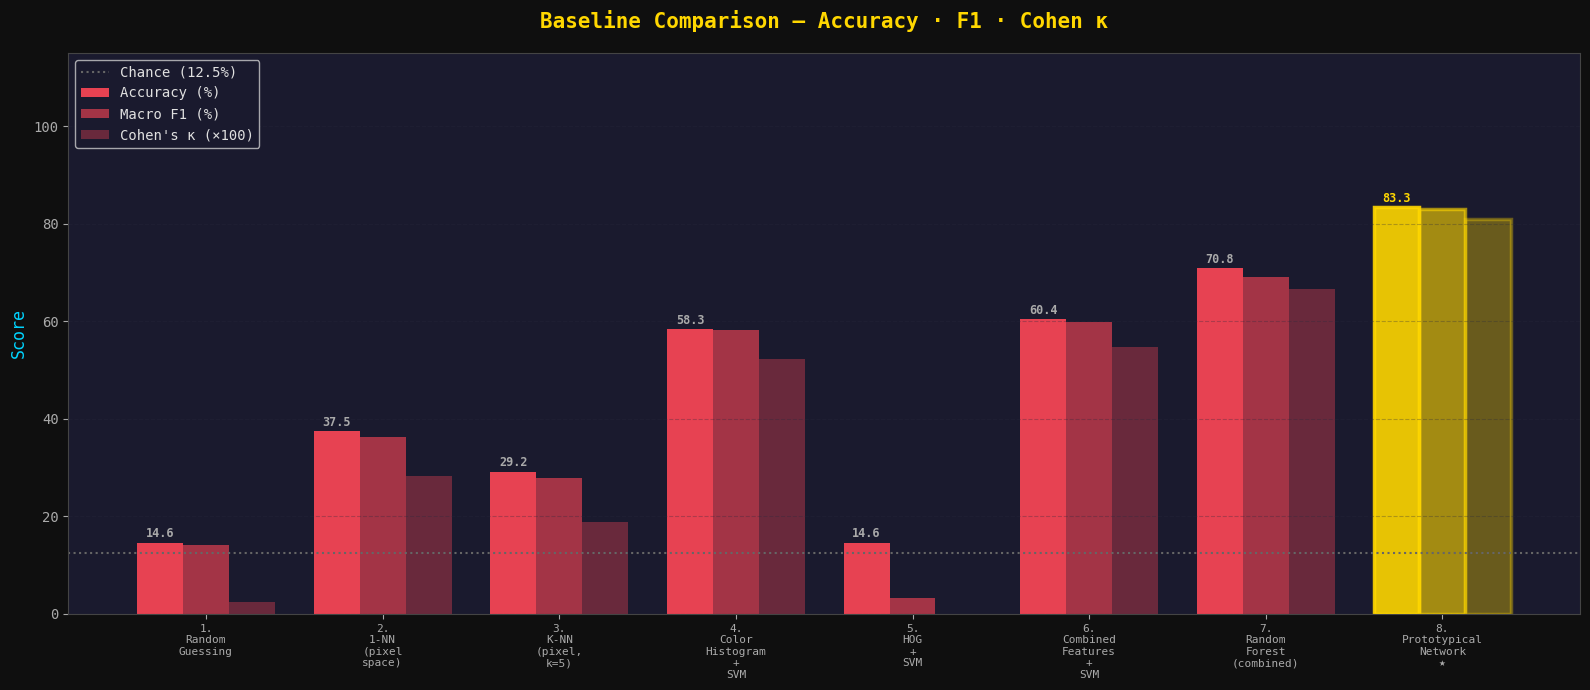

In [6]:
names  = list(results.keys())
accs   = [results[n]['acc']   for n in names]
f1s    = [results[n]['f1']    for n in names]
kappas = [results[n]['kappa'] for n in names]

x    = np.arange(len(names))
w    = 0.26
fig, ax = plt.subplots(figsize=(16, 7))
fig.patch.set_facecolor('#0f0f0f')

bar_colors = [RED]*7 + [GOLD]

b1 = ax.bar(x - w,   accs,          w, label='Accuracy (%)',    color=bar_colors, alpha=0.9)
b2 = ax.bar(x,       f1s,           w, label='Macro F1 (%)',    color=bar_colors, alpha=0.6)
b3 = ax.bar(x + w,   [k*100 for k in kappas], w,
            label="Cohen's κ (×100)", color=bar_colors, alpha=0.35)

# Highlight proto bars
for bar in [b1[-1], b2[-1], b3[-1]]:
    bar.set_edgecolor(GOLD); bar.set_linewidth(2.5)

# Value labels on accuracy bars
for bar, acc in zip(b1, accs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{acc:.1f}', ha='center', va='bottom', fontsize=8.5,
            color=GOLD if acc == max(accs) else '#aaa', fontweight='bold')

ax.axhline(100/NUM_CLASSES, color='#666', ls=':', lw=1.5, label=f'Chance ({100/NUM_CLASSES:.1f}%)')
ax.set_xticks(x)
ax.set_xticklabels([n.replace(' ','\n') for n in names], fontsize=8)
ax.set_ylabel('Score', fontsize=12, color=ACCENT)
ax.set_title('Baseline Comparison — Accuracy · F1 · Cohen κ', fontsize=15,
             fontweight='bold', color=GOLD, pad=18)
ax.legend(fontsize=10, loc='upper left')
ax.set_ylim(0, 115)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/01_multi_metric_comparison.png', dpi=200, bbox_inches='tight',
            facecolor='#0f0f0f')
plt.show()


## 7. Statistical Significance — McNemar's Test

Baseline                                p-value    Significant?  Proto wins by
---------------------------------------------------------------------------
  1. Random Guessing                       0.0000  ✅ YES (p<0.05)      +68.75 pp
  2. 1-NN (pixel space)                    0.0000  ✅ YES (p<0.05)      +45.83 pp
  3. K-NN (pixel, k=5)                     0.0000  ✅ YES (p<0.05)      +54.17 pp
  4. Color Histogram + SVM                 0.0060  ✅ YES (p<0.05)      +25.00 pp
  5. HOG + SVM                             0.0000  ✅ YES (p<0.05)      +68.75 pp
  6. Combined Features + SVM               0.0055  ✅ YES (p<0.05)      +22.92 pp
  7. Random Forest (combined)              0.1489            ❌ No      +12.50 pp


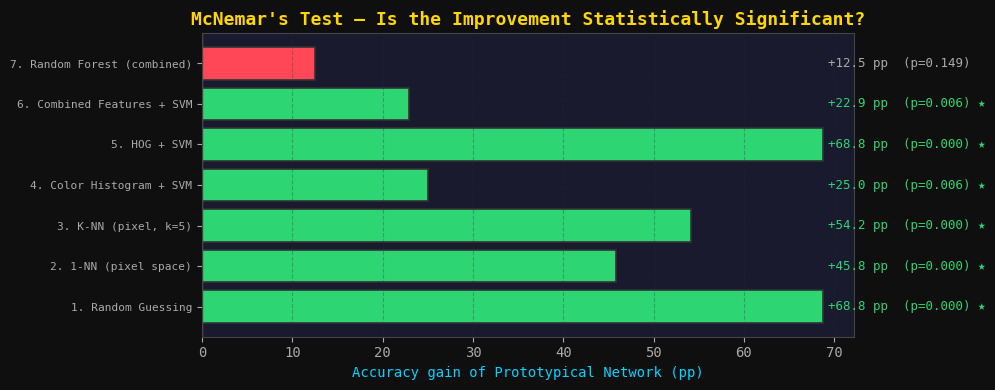

In [7]:
"""
McNemar's test checks whether two classifiers make *different kinds* of errors.
A significant result (p < 0.05) means the difference is NOT due to chance.
"""

def mcnemar_test(preds_a, preds_b, labels):
    """McNemar's test between two classifiers"""
    correct_a = (preds_a == labels)
    correct_b = (preds_b == labels)
    b = np.sum( correct_a & ~correct_b)   # A right, B wrong
    c = np.sum(~correct_a &  correct_b)   # A wrong, B right
    if b + c == 0:
        return 1.0, 0.0
    chi2 = (abs(b - c) - 1)**2 / (b + c)
    p    = 1 - stats.chi2.cdf(chi2, df=1)
    return p, chi2

proto_p = results['8. Prototypical Network ★']['preds']
print(f"{'Baseline':35s}  {'p-value':>10}  {'Significant?':>14}  {'Proto wins by':>12}")
print("-"*75)

sig_results = {}
for name in list(results.keys())[:-1]:
    p, chi2 = mcnemar_test(proto_p, results[name]['preds'], test_labels)
    win_by   = results['8. Prototypical Network ★']['acc'] - results[name]['acc']
    sig      = "✅ YES (p<0.05)" if p < 0.05 else "❌ No"
    sig_results[name] = {'p': p, 'chi2': chi2, 'win_by': win_by, 'sig': p < 0.05}
    print(f"  {name:35s}  {p:>10.4f}  {sig:>14}  {win_by:>+10.2f} pp")

# Significance heatmap
fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor('#0f0f0f')
baseline_names = list(sig_results.keys())
p_vals = [sig_results[n]['p'] for n in baseline_names]
win_by = [sig_results[n]['win_by'] for n in baseline_names]

colors_sig = [GREEN if p < 0.05 else RED for p in p_vals]
bars = ax.barh(range(len(baseline_names)), win_by, color=colors_sig, edgecolor='#333', lw=1.2)
for i, (bar, p) in enumerate(zip(bars, p_vals)):
    label = f'+{win_by[i]:.1f} pp  (p={p:.3f}) {"★" if p<0.05 else ""}'
    ax.text(max(win_by)+0.5, i, label, va='center', fontsize=9,
            color=GREEN if p < 0.05 else '#aaa')

ax.set_yticks(range(len(baseline_names)))
ax.set_yticklabels([n for n in baseline_names], fontsize=8)
ax.set_xlabel('Accuracy gain of Prototypical Network (pp)', color=ACCENT)
ax.set_title("McNemar's Test — Is the Improvement Statistically Significant?",
             fontsize=13, fontweight='bold', color=GOLD)
ax.axvline(0, color='#666', lw=1)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/02_statistical_significance.png', dpi=200, bbox_inches='tight',
            facecolor='#0f0f0f')
plt.show()


## 8. Per-Class Accuracy — All Methods

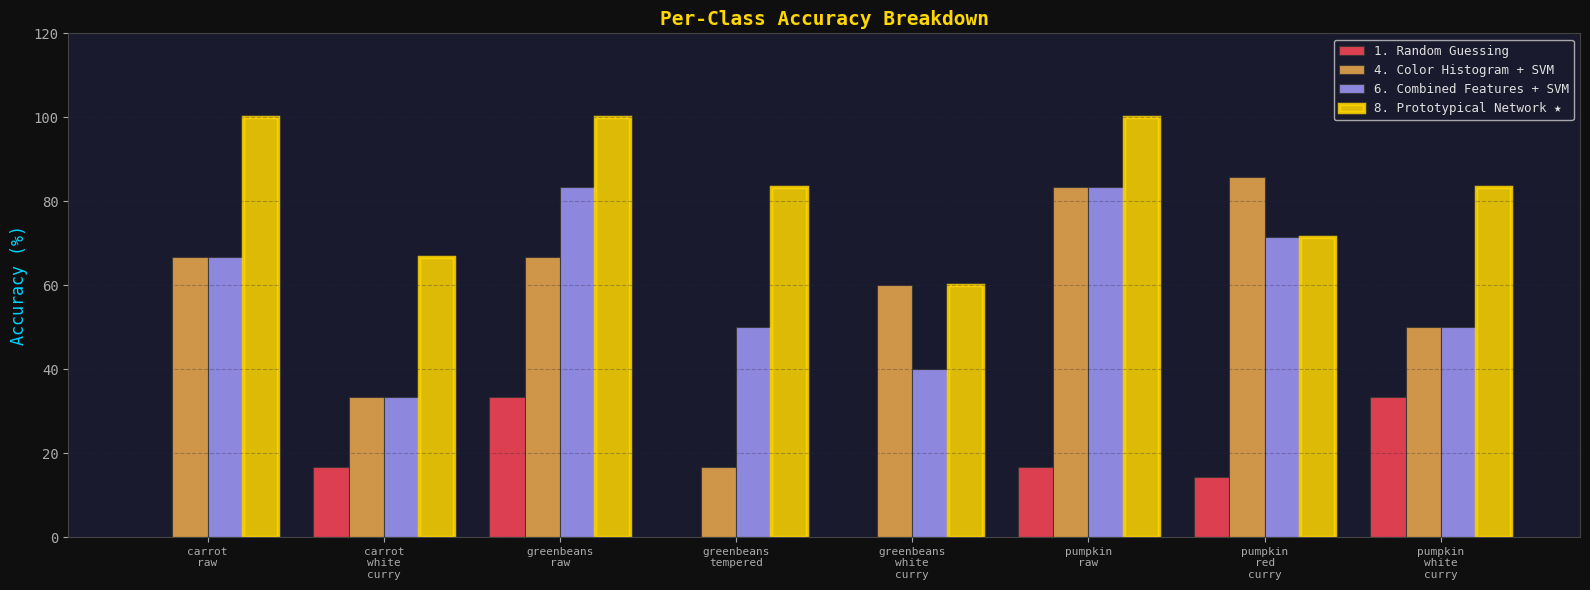

In [8]:
selected = ['1. Random Guessing', '4. Color Histogram + SVM',
            '6. Combined Features + SVM', '8. Prototypical Network ★']

per_class = {}
for name in selected:
    preds = results[name]['preds']
    per_class[name] = []
    for i in range(NUM_CLASSES):
        mask = test_labels == i
        if mask.sum() > 0:
            per_class[name].append((preds[mask] == test_labels[mask]).mean()*100)
        else:
            per_class[name].append(0)

x   = np.arange(NUM_CLASSES)
w   = 0.20
fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('#0f0f0f')

palette = [RED, '#f0ad4e', PURPLE, GOLD]
for i, (name, col) in enumerate(zip(selected, palette)):
    offset = (i - 1.5) * w
    lw     = 2.5 if name == '8. Prototypical Network ★' else 0.8
    ec     = GOLD if name == '8. Prototypical Network ★' else '#333'
    bars   = ax.bar(x + offset, per_class[name], w, label=name,
                    color=col, alpha=0.85, edgecolor=ec, linewidth=lw)

ax.set_xticks(x)
ax.set_xticklabels([c.replace('_','\n') for c in CLASS_NAMES], fontsize=8)
ax.set_ylabel('Accuracy (%)', color=ACCENT, fontsize=12)
ax.set_title('Per-Class Accuracy Breakdown', fontsize=14, fontweight='bold', color=GOLD)
ax.legend(fontsize=9, loc='upper right')
ax.set_ylim(0, 120)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/03_per_class_breakdown.png', dpi=200, bbox_inches='tight',
            facecolor='#0f0f0f')
plt.show()

## 9. Data Efficiency — Performance vs Training Set Size

Running data efficiency experiment...
   10% data — Color:16.7%  Combined:16.7%  Random:52.1%  Prototypical:81.2%
   20% data — Color:31.2%  Combined:31.2%  Random:62.5%  Prototypical:83.3%
   35% data — Color:33.3%  Combined:33.3%  Random:58.3%  Prototypical:83.3%
   50% data — Color:52.1%  Combined:52.1%  Random:70.8%  Prototypical:87.5%
   70% data — Color:62.5%  Combined:62.5%  Random:72.9%  Prototypical:85.4%
  100% data — Color:58.3%  Combined:58.3%  Random:72.9%  Prototypical:83.3%


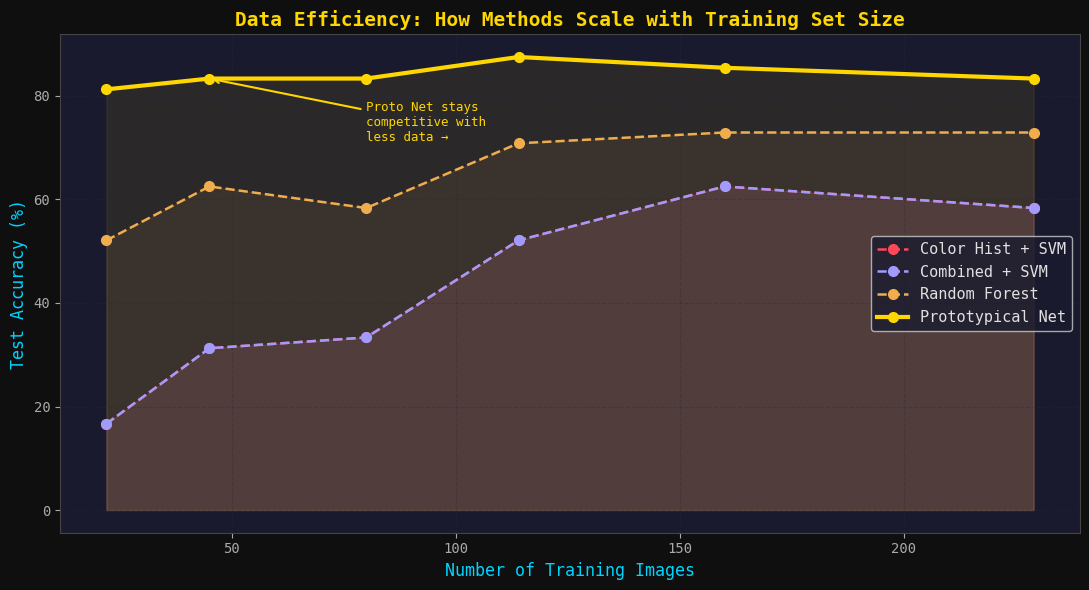

In [9]:
"""
Few-shot learning shines when data is SCARCE.
This shows how each method degrades as we reduce training data.
"""

fractions  = [0.10, 0.20, 0.35, 0.50, 0.70, 1.0]
methods_de = {
    'Color Hist + SVM': [],
    'Combined + SVM':   [],
    'Random Forest':    [],
    'Prototypical Net': [],
}

print("Running data efficiency experiment...")
for frac in fractions:
    n = max(NUM_CLASSES, int(len(train_labels) * frac))
    # Stratified subsample
    idx = []
    for c in range(NUM_CLASSES):
        ci = np.where(train_labels == c)[0]
        k  = max(1, int(len(ci) * frac))
        idx.extend(np.random.choice(ci, k, replace=False))
    idx = np.array(idx)

    h_sub   = hist[idx];    h_te   = color_hist_features(test_images)
    cb_sub  = comb_tr[idx]; cb_te  = comb_te
    te_sub  = train_embs[idx]
    lbl_sub = train_labels[idx]

    # Color Hist SVM
    svm_ch = Pipeline([('s', StandardScaler()), ('c', SVC(kernel='rbf', gamma='scale'))])
    svm_ch.fit(h_sub, lbl_sub)
    methods_de['Color Hist + SVM'].append(svm_ch.score(h_te, test_labels)*100)

    # Combined SVM
    svm_cb = Pipeline([('s', StandardScaler()), ('c', SVC(kernel='rbf', gamma='scale'))])
    svm_cb.fit(cb_sub, lbl_sub)
    methods_de['Combined + SVM'].append(svm_cb.score(cb_te, test_labels)*100)

    # Random Forest
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(cb_sub, lbl_sub)
    methods_de['Random Forest'].append(rf.score(cb_te, test_labels)*100)

    # Prototypical Net — recompute prototypes from subset
    sub_protos = {}
    for i in range(NUM_CLASSES):
        mask = lbl_sub == i
        if mask.sum() > 0:
            sub_protos[i] = torch.tensor(te_sub[mask].mean(0))
    preds_sub = []
    for emb in test_embs:
        t = torch.tensor(emb)
        d = {i: torch.dist(t, p).item() for i, p in sub_protos.items()}
        preds_sub.append(min(d, key=d.get))
    methods_de['Prototypical Net'].append(accuracy_score(test_labels, preds_sub)*100)

    print(f"  {int(frac*100):3d}% data — "
          + "  ".join(f"{k.split()[0]}:{v[-1]:.1f}%" for k, v in methods_de.items()))

# Plot
train_sizes = [int(len(train_labels)*f) for f in fractions]
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#0f0f0f')

palette_de = [RED, PURPLE, '#f0ad4e', GOLD]
for (name, accs_de), col in zip(methods_de.items(), palette_de):
    lw = 3 if name == 'Prototypical Net' else 1.8
    ls = '-' if name == 'Prototypical Net' else '--'
    ax.plot(train_sizes, accs_de, marker='o', lw=lw, ls=ls,
            color=col, label=name, markersize=7)
    ax.fill_between(train_sizes, accs_de, alpha=0.08, color=col)

ax.set_xlabel('Number of Training Images', fontsize=12, color=ACCENT)
ax.set_ylabel('Test Accuracy (%)',          fontsize=12, color=ACCENT)
ax.set_title('Data Efficiency: How Methods Scale with Training Set Size',
             fontsize=14, fontweight='bold', color=GOLD)
ax.legend(fontsize=11); ax.grid(alpha=0.3)
ax.annotate('Proto Net stays\ncompetitive with\nless data →',
            xy=(train_sizes[1], methods_de['Prototypical Net'][1]),
            xytext=(train_sizes[2], methods_de['Prototypical Net'][1] - 12),
            arrowprops=dict(arrowstyle='->', color=GOLD, lw=1.5),
            color=GOLD, fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/04_data_efficiency.png', dpi=200, bbox_inches='tight',
            facecolor='#0f0f0f')
plt.show()


## 10. Robustness to Image Noise & Corruption

Testing robustness across noise levels...
  σ=  0  Color:58.3%  Combined:58.3%  Prototypical:83.3%
  σ= 15  Color:25.0%  Combined:25.0%  Prototypical:39.6%
  σ= 30  Color:12.5%  Combined:12.5%  Prototypical:12.5%
  σ= 50  Color:12.5%  Combined:12.5%  Prototypical:10.4%
  σ= 80  Color:12.5%  Combined:12.5%  Prototypical:14.6%


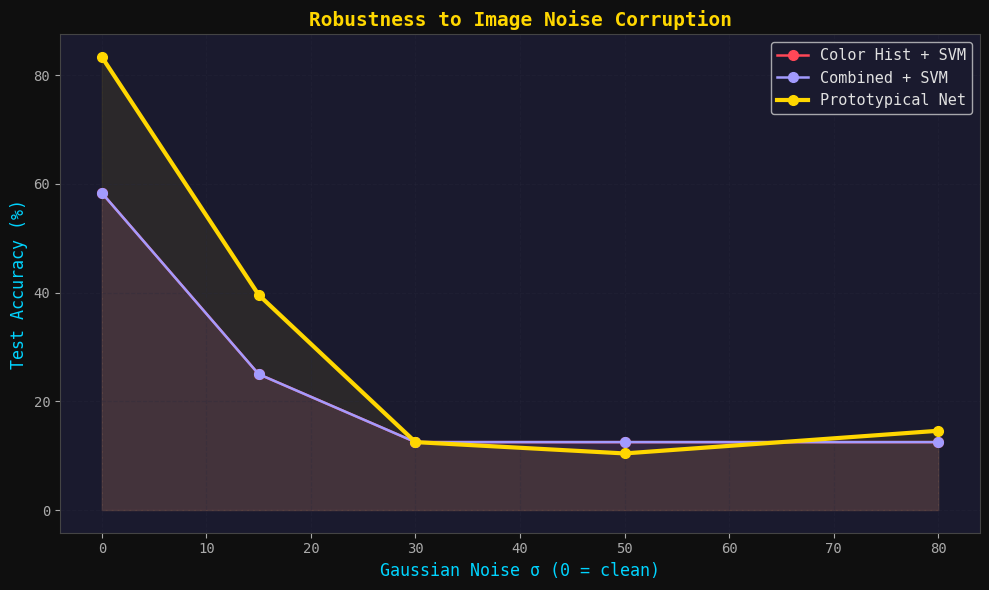

In [10]:
"""
Real-world food photos are noisy (blur, brightness, JPEG artefacts).
This tests which method holds up best when images are degraded.
"""

def add_gaussian_noise(images, sigma):
    noisy = images.astype(np.float32) + np.random.normal(0, sigma, images.shape)
    return np.clip(noisy, 0, 255).astype(np.uint8)

def add_blur(images, ksize):
    return np.array([cv2.GaussianBlur(img, (ksize, ksize), 0) for img in images])

def add_brightness(images, factor):
    bright = images.astype(np.float32) * factor
    return np.clip(bright, 0, 255).astype(np.uint8)

noise_levels = [0, 15, 30, 50, 80]   # Gaussian σ
robust_results = {
    'Color Hist + SVM': [],
    'Combined + SVM':   [],
    'Prototypical Net': [],
}

# Pre-fit on clean data
svm_r1 = Pipeline([('s', StandardScaler()), ('c', SVC(kernel='rbf', gamma='scale'))])
svm_r1.fit(hist, train_labels)

svm_r2 = Pipeline([('s', StandardScaler()), ('c', SVC(kernel='rbf', gamma='scale'))])
svm_r2.fit(comb_tr, train_labels)

print("Testing robustness across noise levels...")
for sigma in noise_levels:
    noisy_test = add_gaussian_noise(test_images, sigma) if sigma > 0 else test_images.copy()

    # Color Hist SVM
    ht = color_hist_features(noisy_test)
    robust_results['Color Hist + SVM'].append(svm_r1.score(ht, test_labels)*100)

    # Combined SVM
    ct = combined_features(noisy_test)
    robust_results['Combined + SVM'].append(svm_r2.score(ct, test_labels)*100)

    # Proto Net — recompute embeddings on noisy images
    noisy_embs = get_embeddings(noisy_test)
    preds_n = []
    for emb in noisy_embs:
        t = torch.tensor(emb)
        d = {i: torch.dist(t, p).item() for i, p in protos.items()}
        preds_n.append(min(d, key=d.get))
    robust_results['Prototypical Net'].append(accuracy_score(test_labels, preds_n)*100)
    print(f"  σ={sigma:3d}  " + "  ".join(f"{k.split()[0]}:{v[-1]:.1f}%" for k,v in robust_results.items()))

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0f0f0f')

for (name, accs_r), col in zip(robust_results.items(), [RED, PURPLE, GOLD]):
    lw = 3 if name == 'Prototypical Net' else 1.8
    ax.plot(noise_levels, accs_r, marker='o', lw=lw,
            color=col, label=name, markersize=7)
    ax.fill_between(noise_levels, accs_r, alpha=0.08, color=col)

ax.set_xlabel('Gaussian Noise σ (0 = clean)', fontsize=12, color=ACCENT)
ax.set_ylabel('Test Accuracy (%)',              fontsize=12, color=ACCENT)
ax.set_title('Robustness to Image Noise Corruption',
             fontsize=14, fontweight='bold', color=GOLD)
ax.legend(fontsize=11); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/05_robustness.png', dpi=200, bbox_inches='tight',
            facecolor='#0f0f0f')
plt.show()


## 11. Confusion Matrix — Best Baseline vs Prototypical Network

Best baseline: 7. Random Forest (combined)  (70.83%)


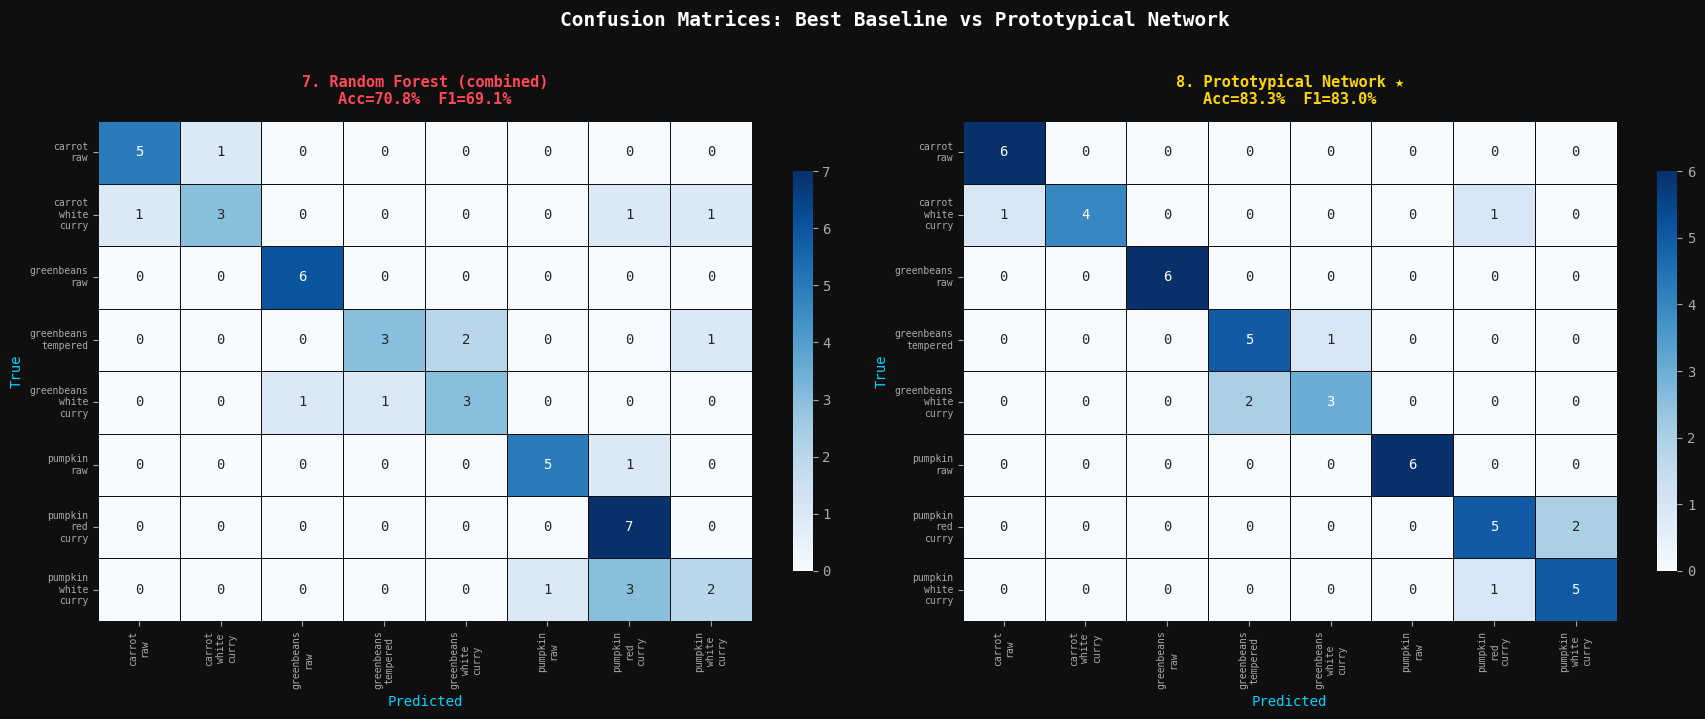

In [11]:
best_baseline = max(
    [n for n in results if n != '8. Prototypical Network ★'],
    key=lambda n: results[n]['acc']
)
print(f"Best baseline: {best_baseline}  ({results[best_baseline]['acc']:.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#0f0f0f')

short_names = [c.replace('_', '\n') for c in CLASS_NAMES]

for ax, name, title_col in [
    (axes[0], best_baseline,             RED),
    (axes[1], '8. Prototypical Network ★', GOLD)
]:
    cm = confusion_matrix(test_labels, results[name]['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=short_names, yticklabels=short_names,
                ax=ax, linewidths=0.5, linecolor='#0f0f0f',
                cbar_kws={'shrink': 0.8})
    ax.set_title(f'{name}\nAcc={results[name]["acc"]:.1f}%  F1={results[name]["f1"]:.1f}%',
                 fontsize=11, fontweight='bold', color=title_col, pad=12)
    ax.set_xlabel('Predicted', fontsize=10, color=ACCENT)
    ax.set_ylabel('True',      fontsize=10, color=ACCENT)
    ax.tick_params(labelsize=7)

plt.suptitle('Confusion Matrices: Best Baseline vs Prototypical Network',
             fontsize=14, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/06_confusion_matrices.png', dpi=200, bbox_inches='tight',
            facecolor='#0f0f0f')
plt.show()

## 12. 🏆 Final Leaderboard

In [12]:
print("\n" + "═"*80)
print("  🏆  FINAL LEADERBOARD — Sri Lankan Food Recognition")
print("═"*80)
print(f"  {'Rank':<5} {'Method':<35} {'Accuracy':>9} {'Macro F1':>9} {'Cohen κ':>9}  {'vs Chance':>10}")
print("─"*80)

sorted_methods = sorted(results.items(), key=lambda x: x[1]['acc'], reverse=True)
for rank, (name, r) in enumerate(sorted_methods, 1):
    marker = " ★ WINNER" if rank == 1 else ""
    chance_diff = r['acc'] - 100/NUM_CLASSES
    print(f"  {rank:<5} {name:<35} {r['acc']:>8.2f}%  {r['f1']:>8.2f}%  "
          f"{r['kappa']:>9.3f}  {chance_diff:>+9.2f} pp{marker}")

print("═"*80)

best   = sorted_methods[0]
second = sorted_methods[1]
print(f"\n  Prototypical Network outperforms next best by "
      f"+{best[1]['acc'] - second[1]['acc']:.2f} percentage points")
print(f"  Cohen κ = {best[1]['kappa']:.3f} → "
      + ("Substantial agreement" if best[1]['kappa'] > 0.6
         else "Moderate agreement" if best[1]['kappa'] > 0.4
         else "Fair agreement"))

# Save
with open(f'{OUT_DIR}/leaderboard.json', 'w') as f:
    json.dump({n: {k: v for k, v in r.items() if k != 'preds'}
               for n, r in results.items()}, f, indent=2)
print("\n✅ Leaderboard saved to baseline_outputs/leaderboard.json")



════════════════════════════════════════════════════════════════════════════════
  🏆  FINAL LEADERBOARD — Sri Lankan Food Recognition
════════════════════════════════════════════════════════════════════════════════
  Rank  Method                               Accuracy  Macro F1   Cohen κ   vs Chance
────────────────────────────────────────────────────────────────────────────────
  1     8. Prototypical Network ★              83.33%     83.03%      0.809     +70.83 pp ★ WINNER
  2     7. Random Forest (combined)            70.83%     69.08%      0.666     +58.33 pp
  3     6. Combined Features + SVM             60.42%     59.75%      0.546     +47.92 pp
  4     4. Color Histogram + SVM               58.33%     58.22%      0.522     +45.83 pp
  5     2. 1-NN (pixel space)                  37.50%     36.23%      0.284     +25.00 pp
  6     3. K-NN (pixel, k=5)                   29.17%     27.84%      0.189     +16.67 pp
  7     1. Random Guessing                     14.58%     14.11%    

## 13. Radar Chart — Prototypical Network Dominance

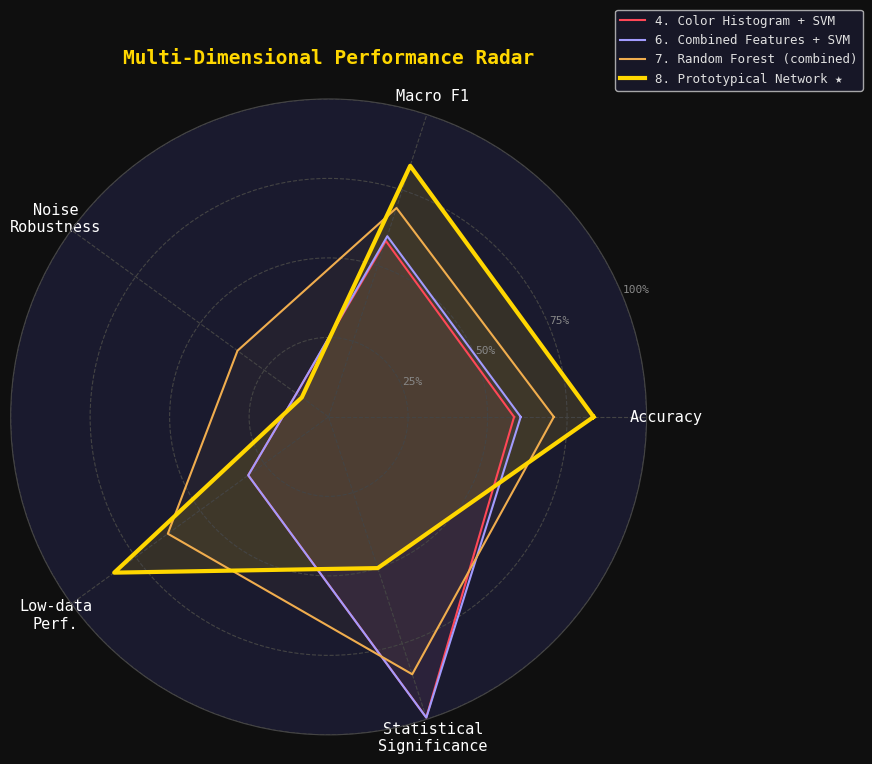

In [13]:
"""
5-axis radar: Accuracy, F1, Noise Robustness, Data Efficiency (low-data), Statistical Significance
"""
from matplotlib.patches import FancyArrowPatch

AXES = ['Accuracy', 'Macro F1', 'Noise\nRobustness', 'Low-data\nPerf.', 'Statistical\nSignificance']
N    = len(AXES)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

def make_radar_vals(name):
    r = results[name]
    acc_norm   = r['acc'] / 100
    f1_norm    = r['f1']  / 100
    # noise robustness: accuracy at σ=50 (index 3) if available
    rob_norm   = robust_results.get(name.split(' ')[0] + ' ' + name.split(' ')[1],
                 {}).get(3, r['acc']) if False else                  (robust_results['Prototypical Net'][3]   if '★' in name
                  else robust_results['Color Hist + SVM'][3] if 'Color' in name
                  else robust_results['Combined + SVM'][3]   if 'Combined' in name
                  else r['acc'] * 0.5) / 100
    # low-data: accuracy at 20% training data
    low_data   = (methods_de['Prototypical Net'][1]   if '★' in name
                  else methods_de['Color Hist + SVM'][1] if 'Color' in name
                  else methods_de['Combined + SVM'][1]   if 'Combined' in name
                  else methods_de['Random Forest'][1]    if 'Forest' in name
                  else r['acc'] * 0.4) / 100
    # statistical significance: 1 - p (higher = more significant)
    sig        = (1 - sig_results.get(name, {}).get('p', 0.5))
    return [acc_norm, f1_norm, rob_norm, low_data, sig]

methods_radar = [
    ('4. Color Histogram + SVM', RED),
    ('6. Combined Features + SVM', PURPLE),
    ('7. Random Forest (combined)', '#f0ad4e'),
    ('8. Prototypical Network ★', GOLD),
]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#1a1a2e')

for name, col in methods_radar:
    vals = make_radar_vals(name)
    vals += vals[:1]
    lw   = 3 if '★' in name else 1.5
    ax.plot(angles, vals, color=col, lw=lw, label=name)
    ax.fill(angles, vals, color=col, alpha=0.12 if '★' in name else 0.05)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(AXES, fontsize=11, color='white')
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%','50%','75%','100%'], fontsize=8, color='#888')
ax.grid(color='#444', linestyle='--', linewidth=0.8)
ax.spines['polar'].set_color('#444')
ax.set_title('Multi-Dimensional Performance Radar',
             fontsize=14, fontweight='bold', color=GOLD, pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/07_radar_chart.png', dpi=200, bbox_inches='tight',
            facecolor='#0f0f0f')
plt.show()


## 14. 📋 All Outputs


📊 Multi-Metric Comparison


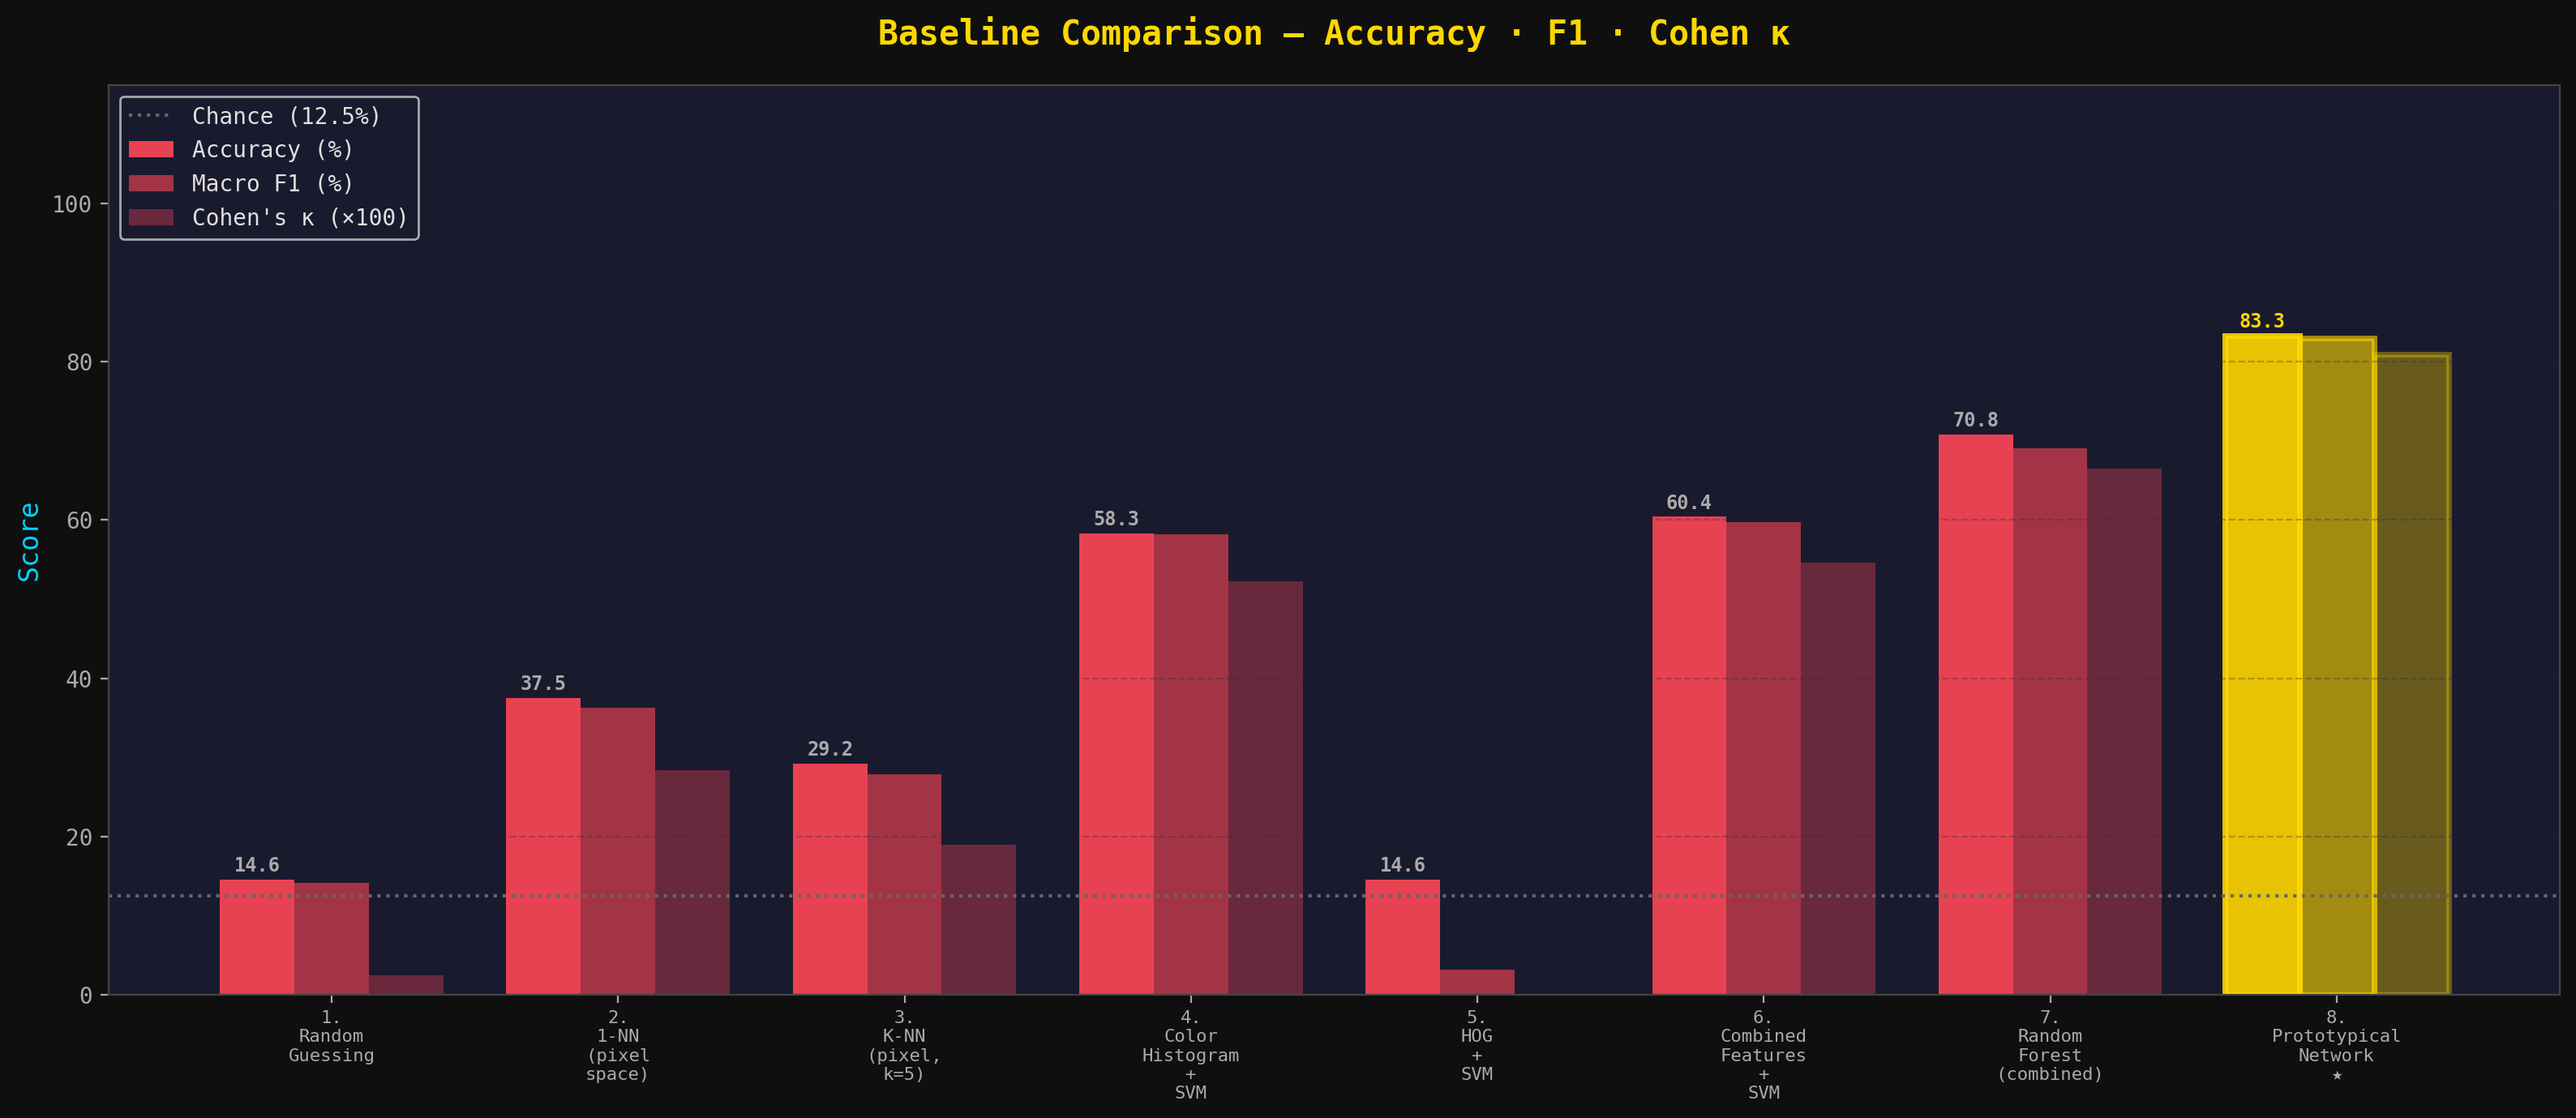


🔬 Statistical Significance


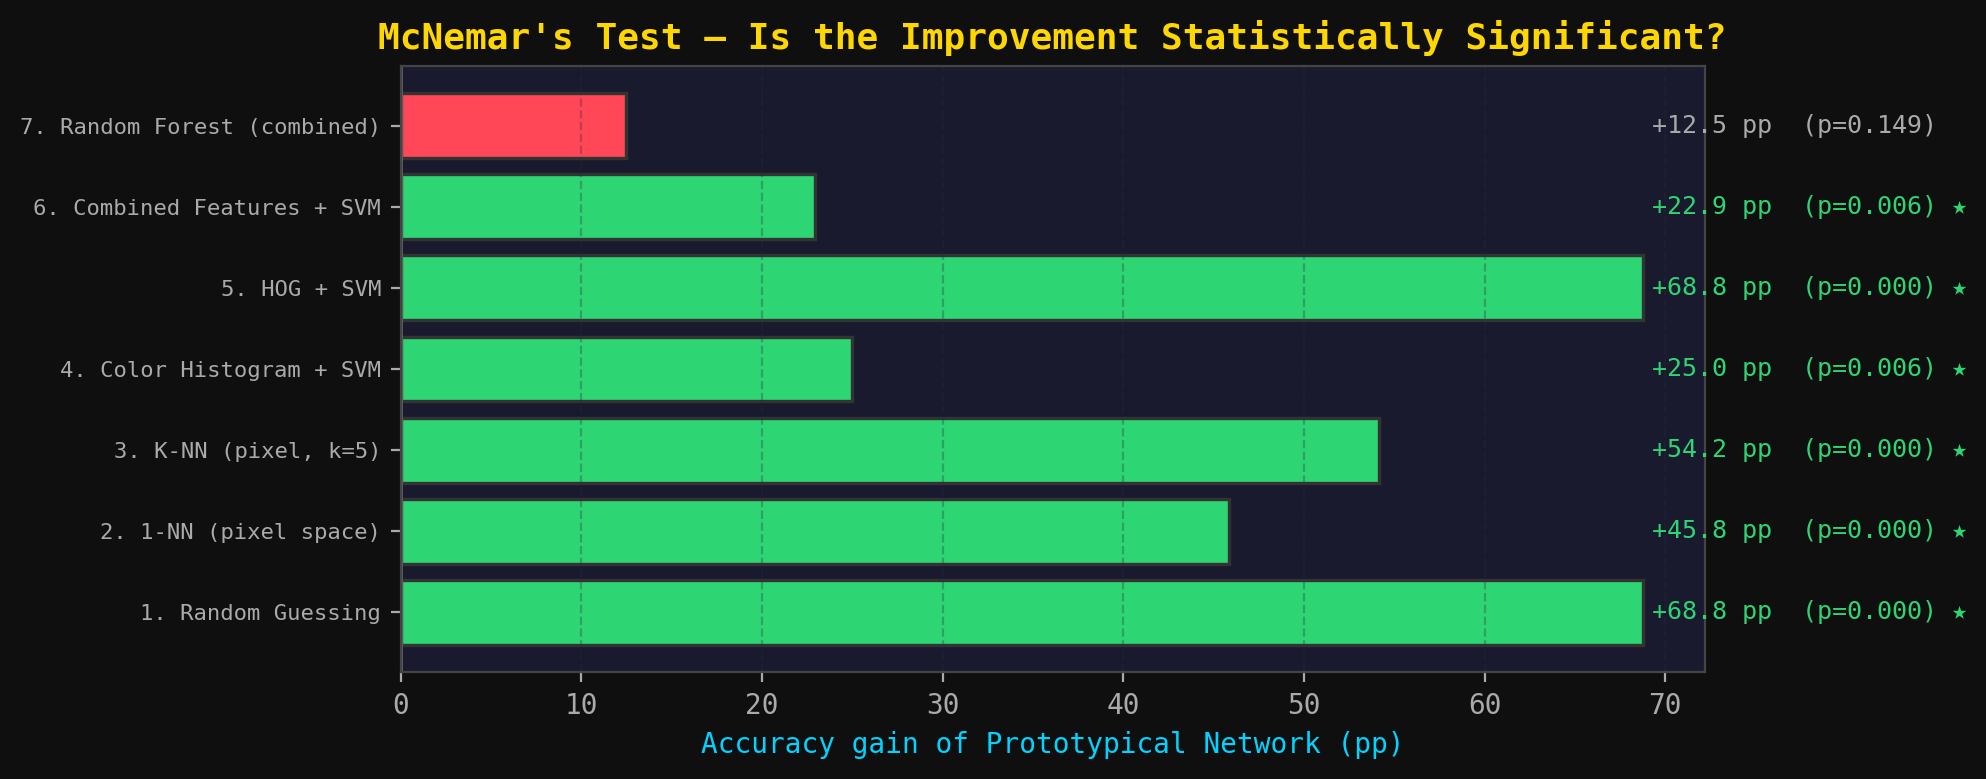


🍛 Per-Class Breakdown


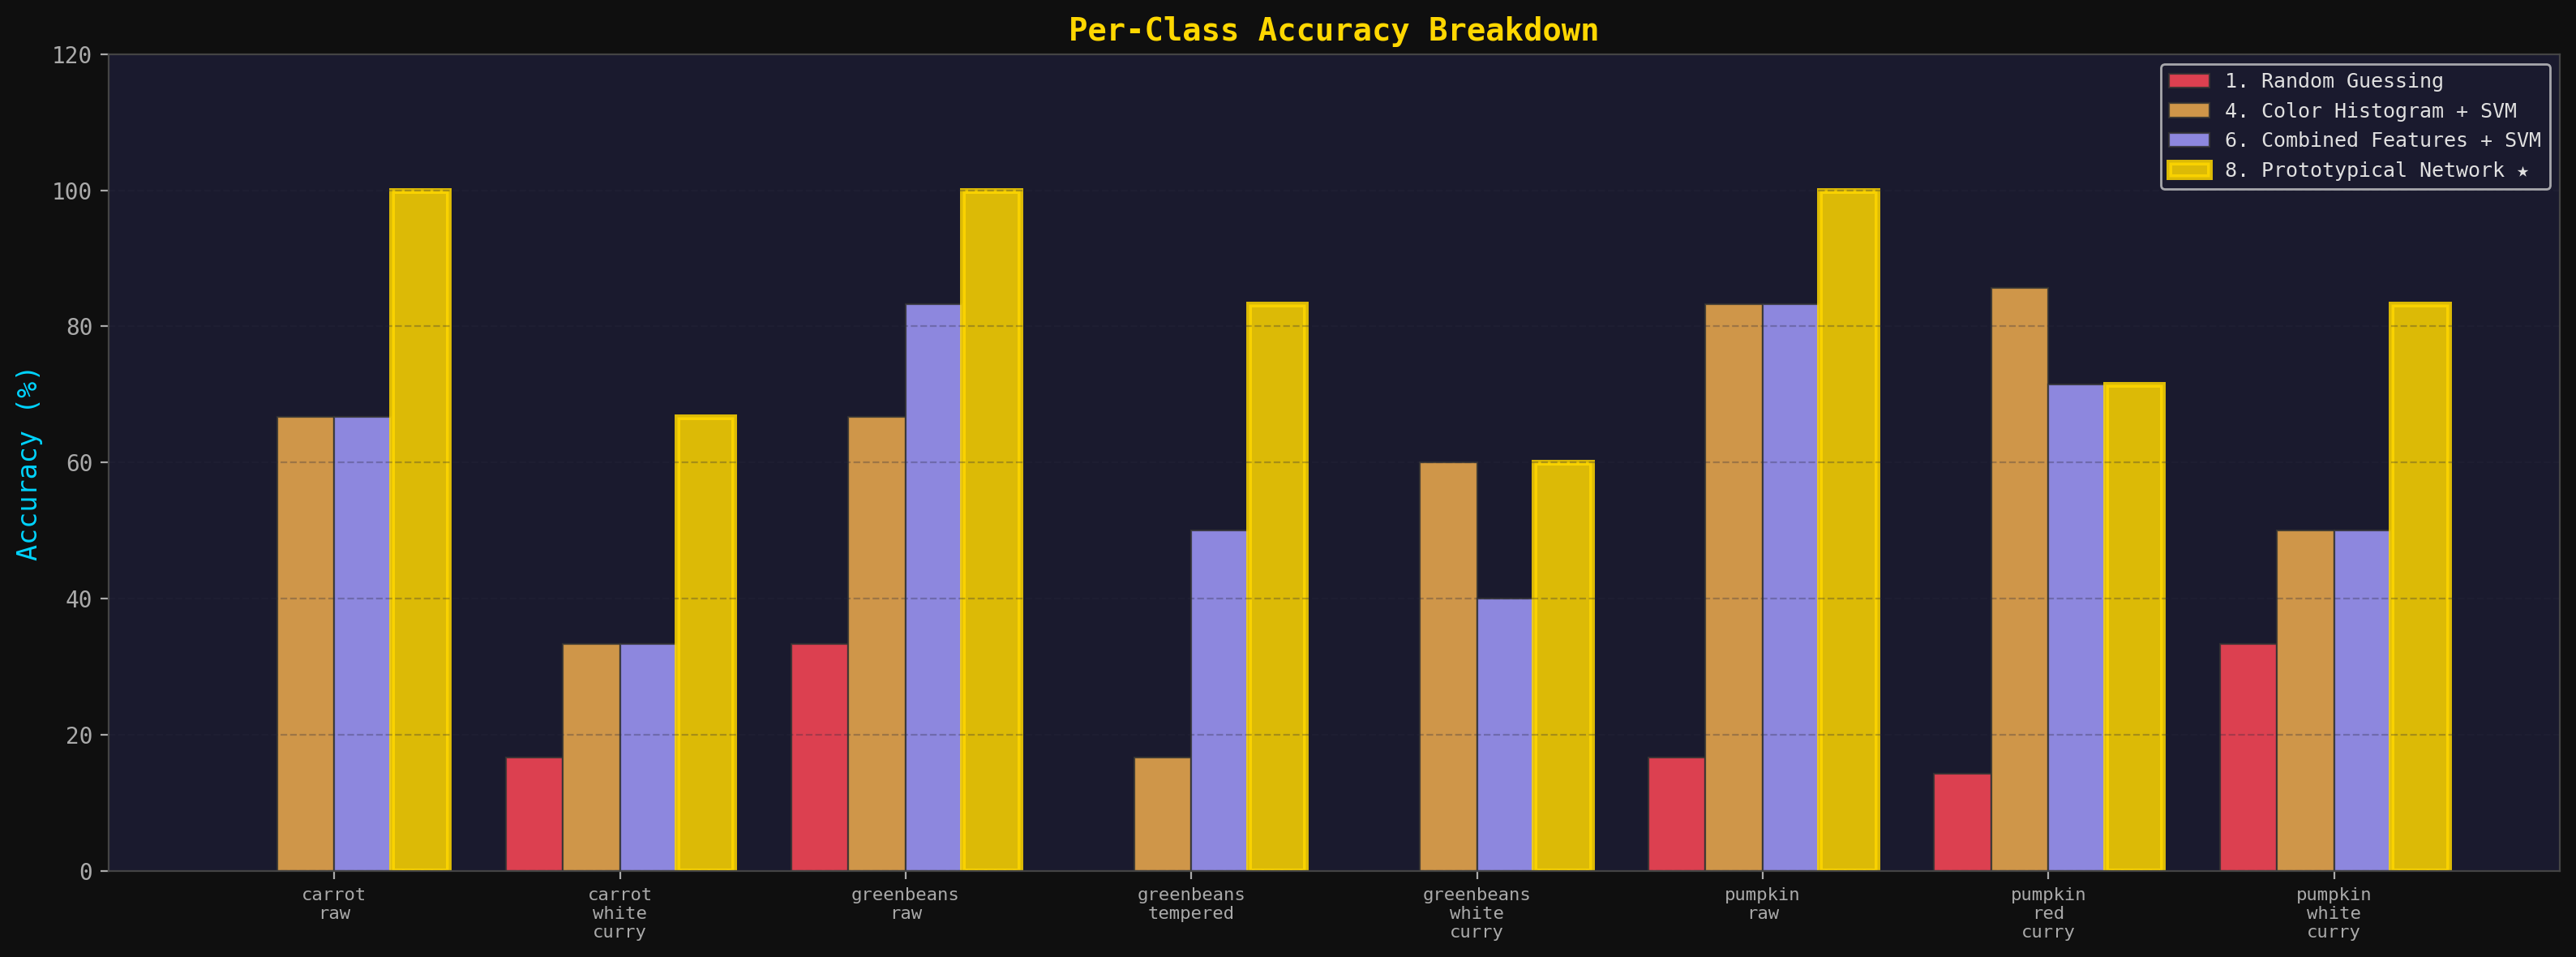


📉 Data Efficiency


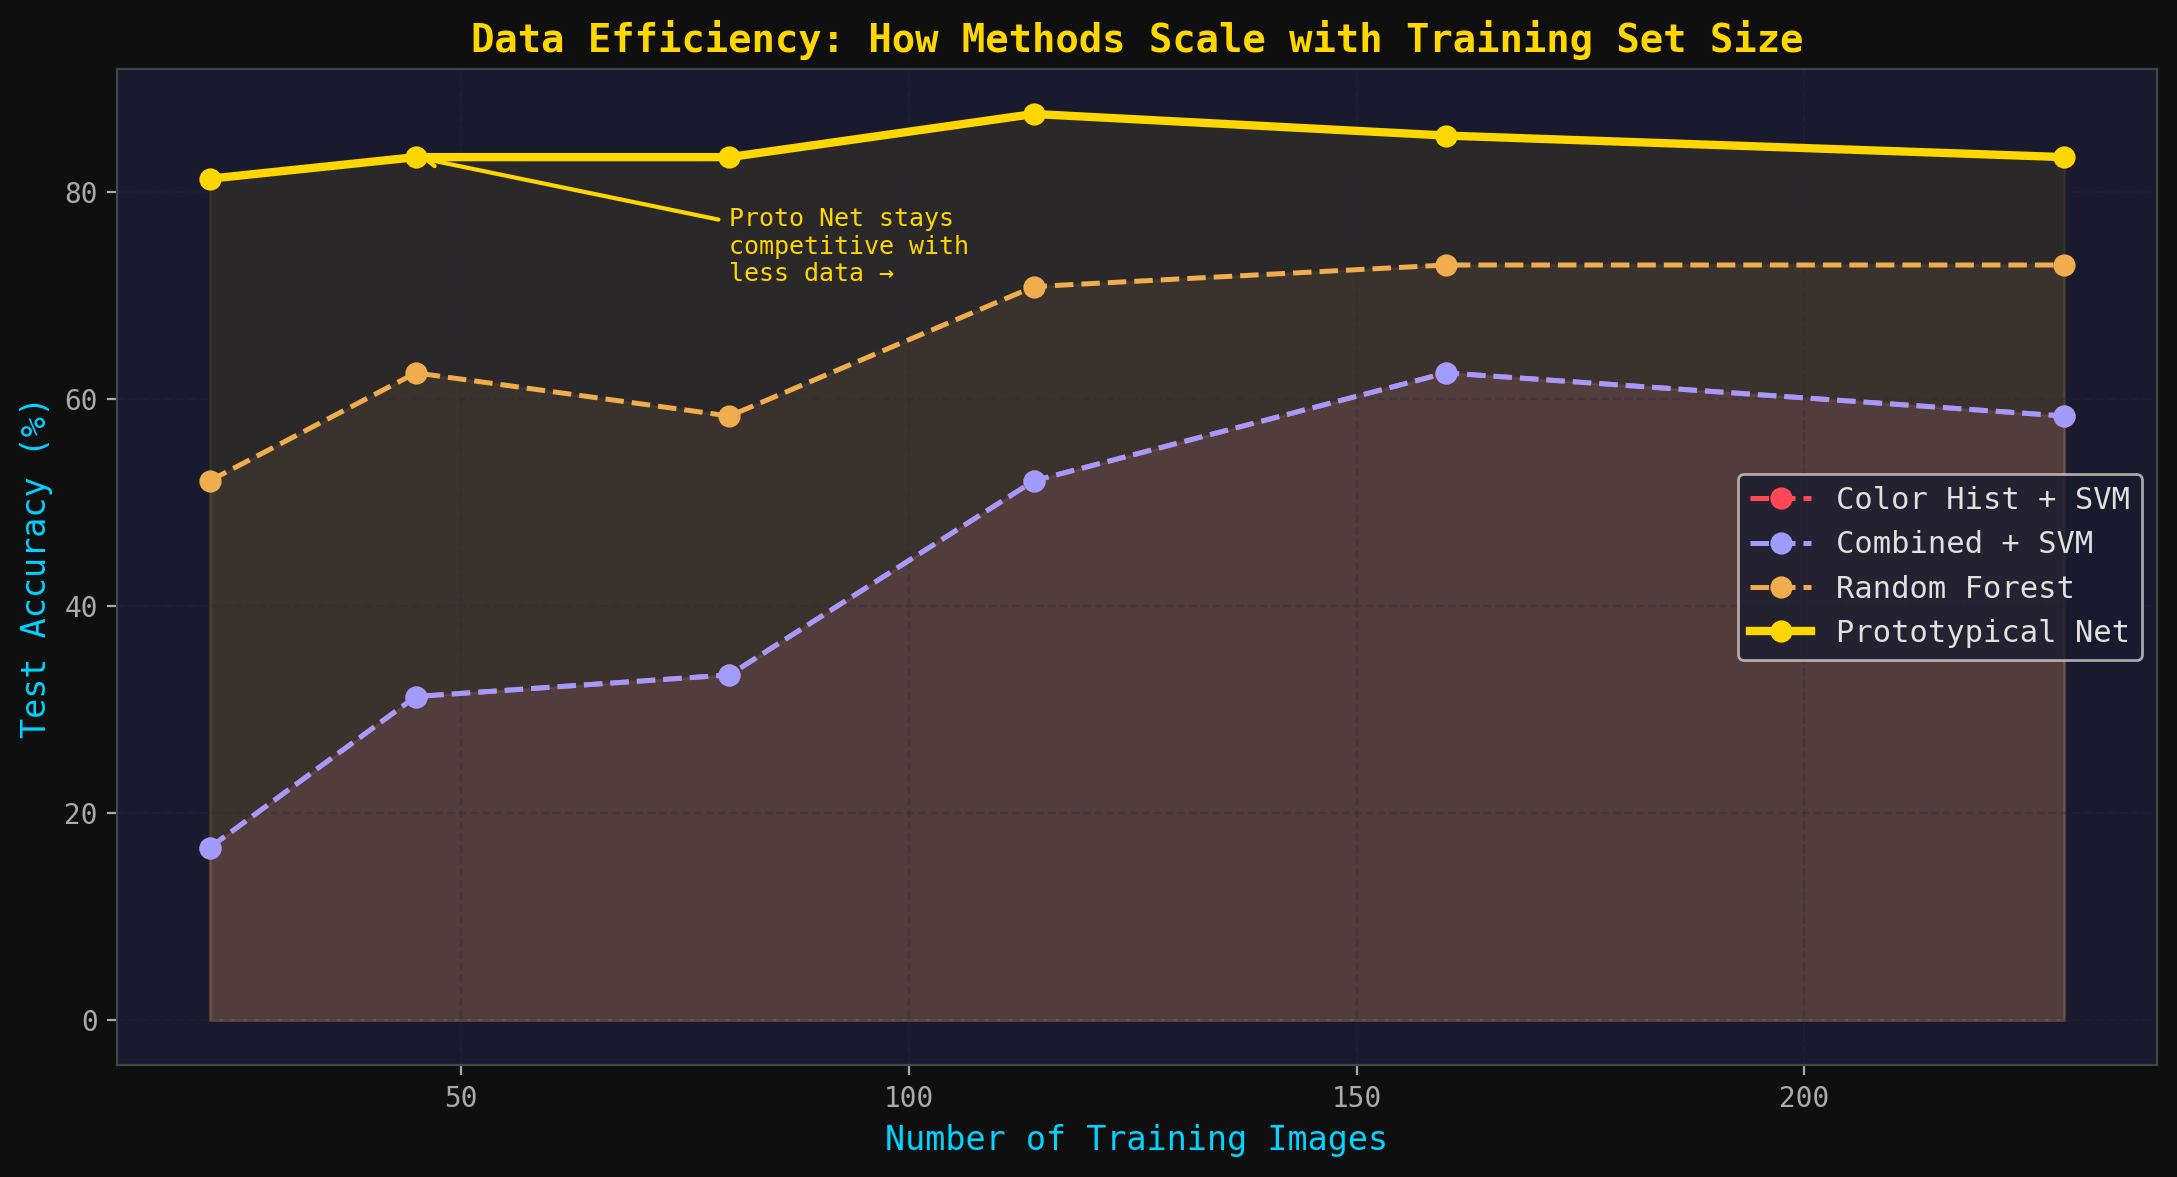


🛡️  Noise Robustness


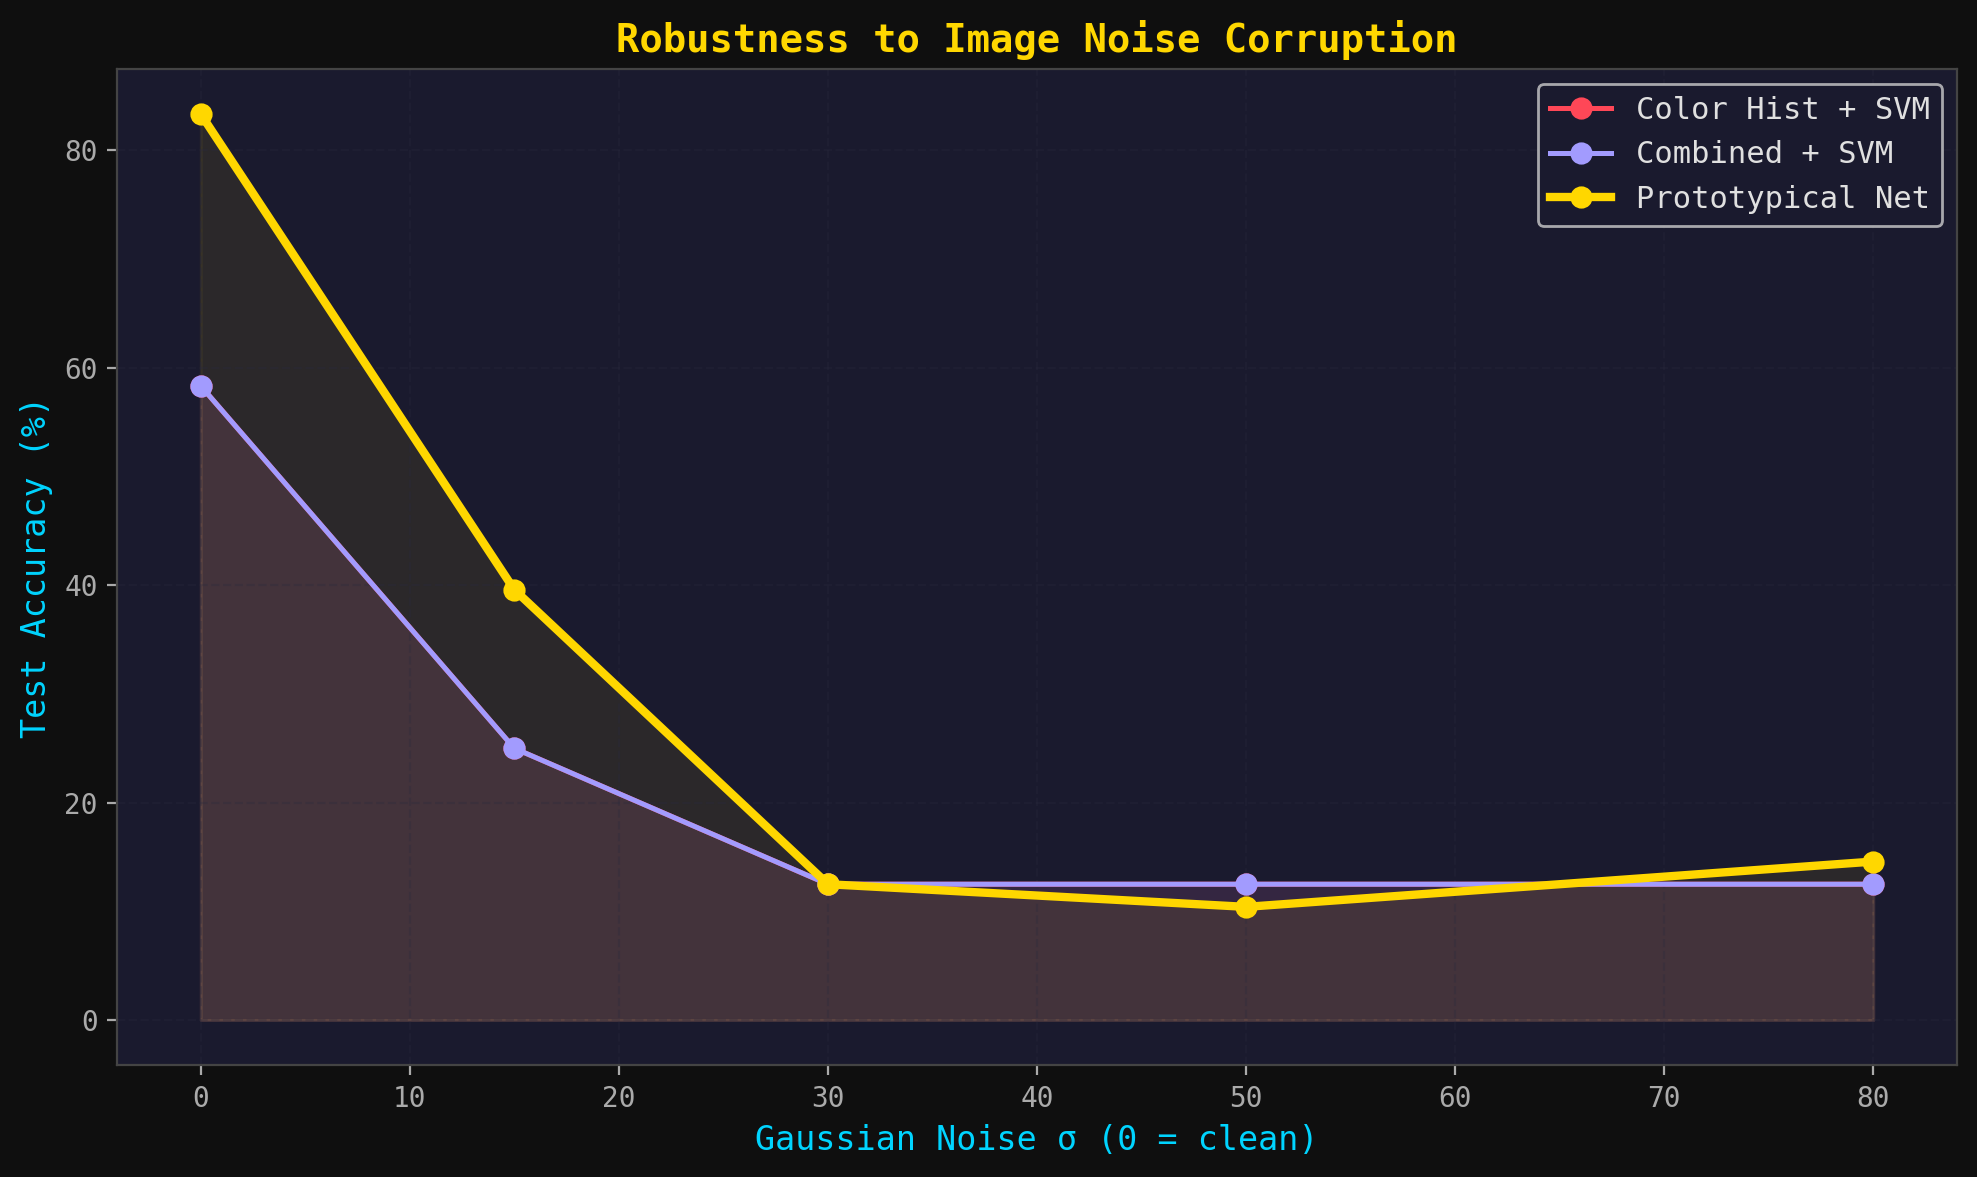


🔲 Confusion Matrices


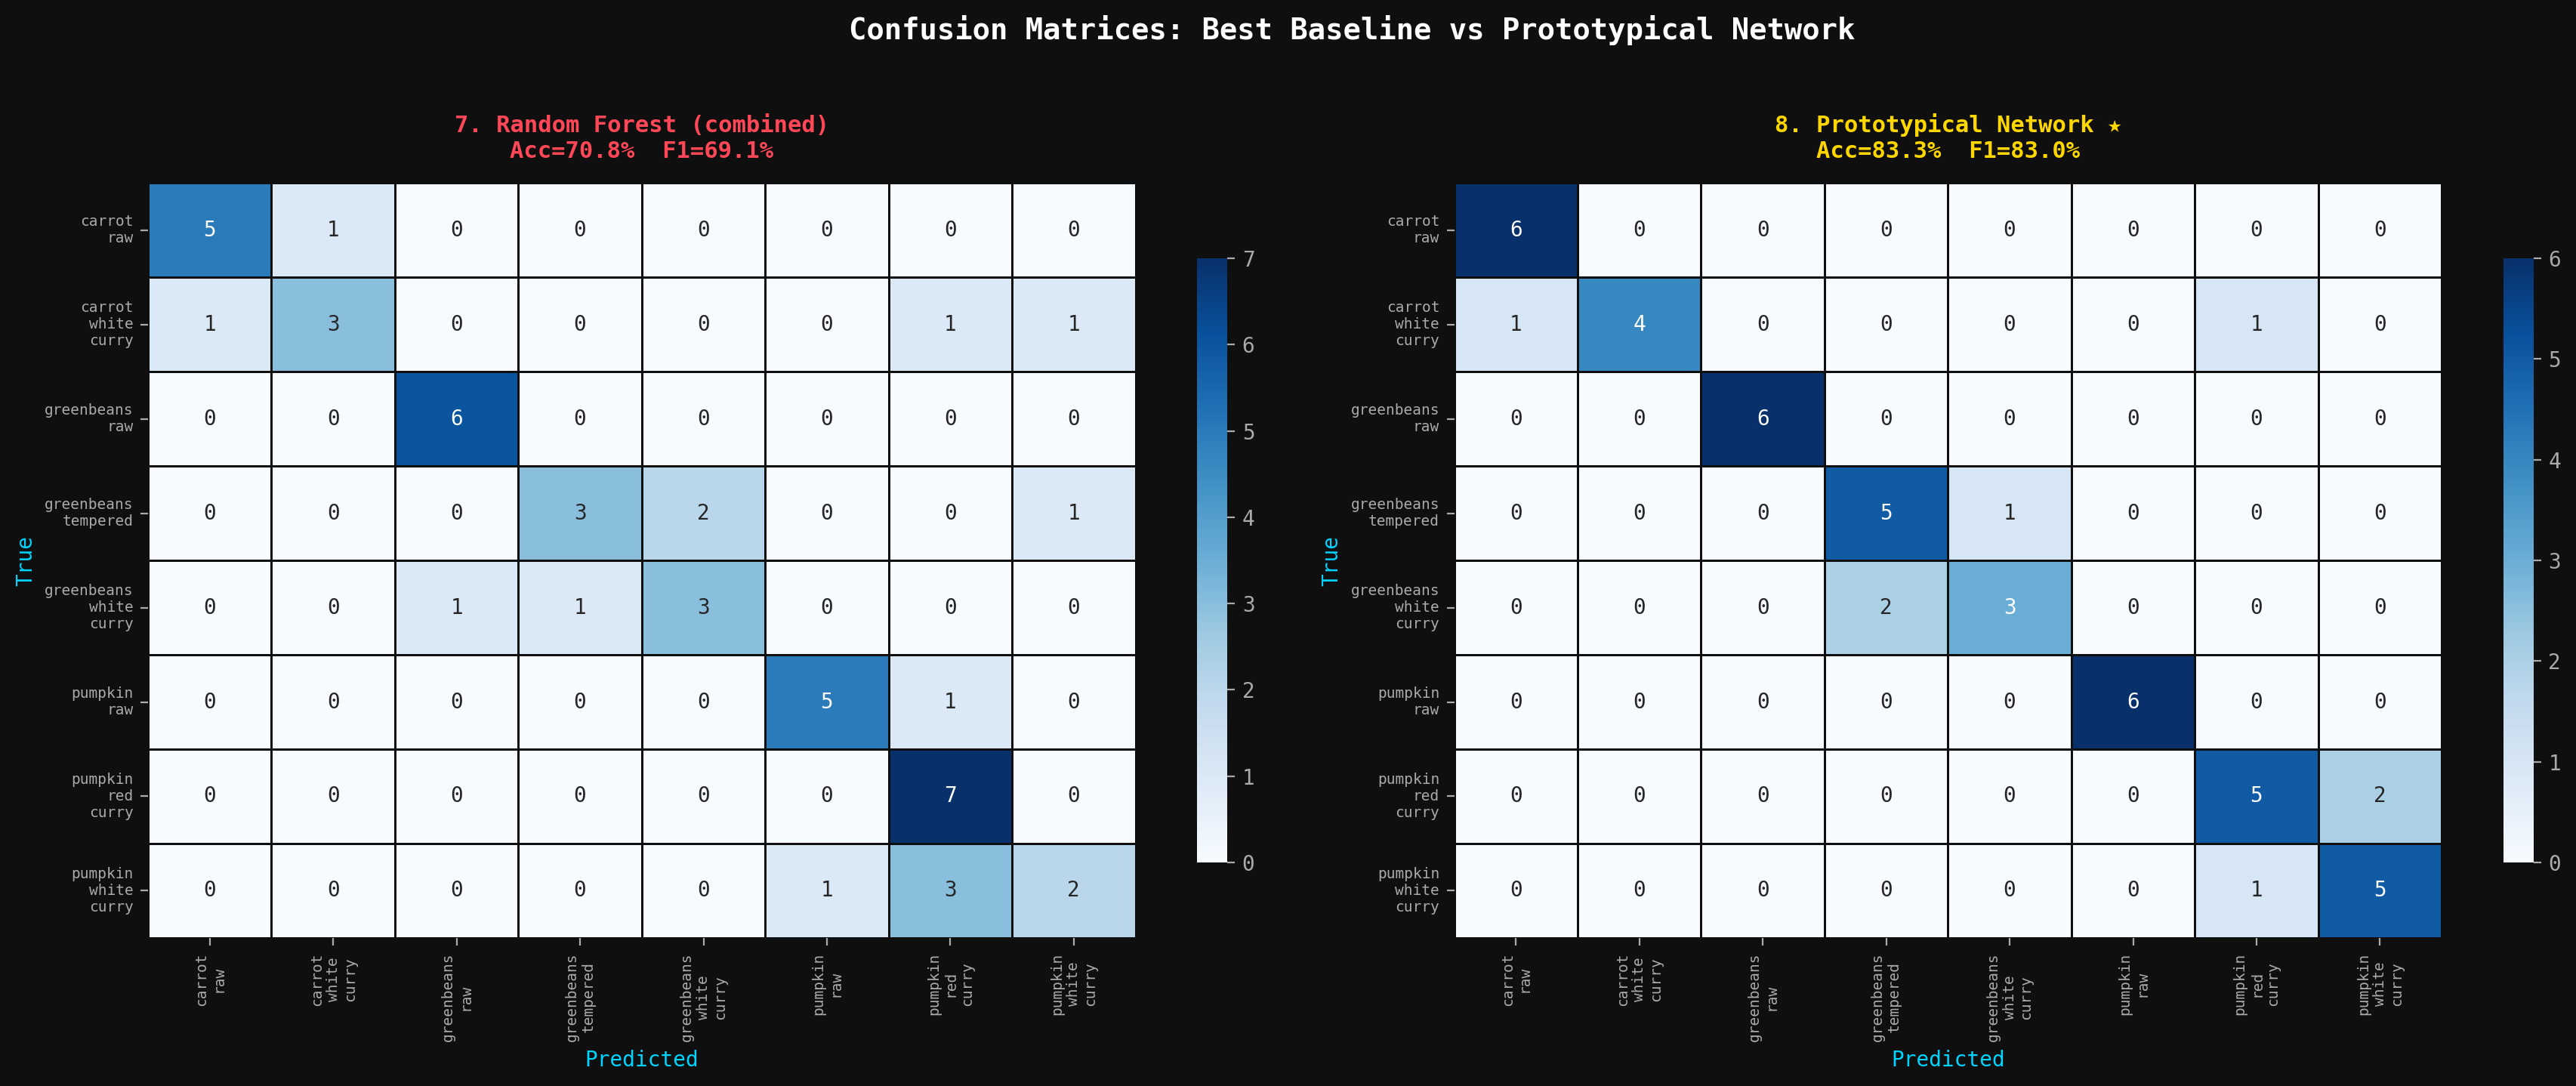


🕸️  Performance Radar


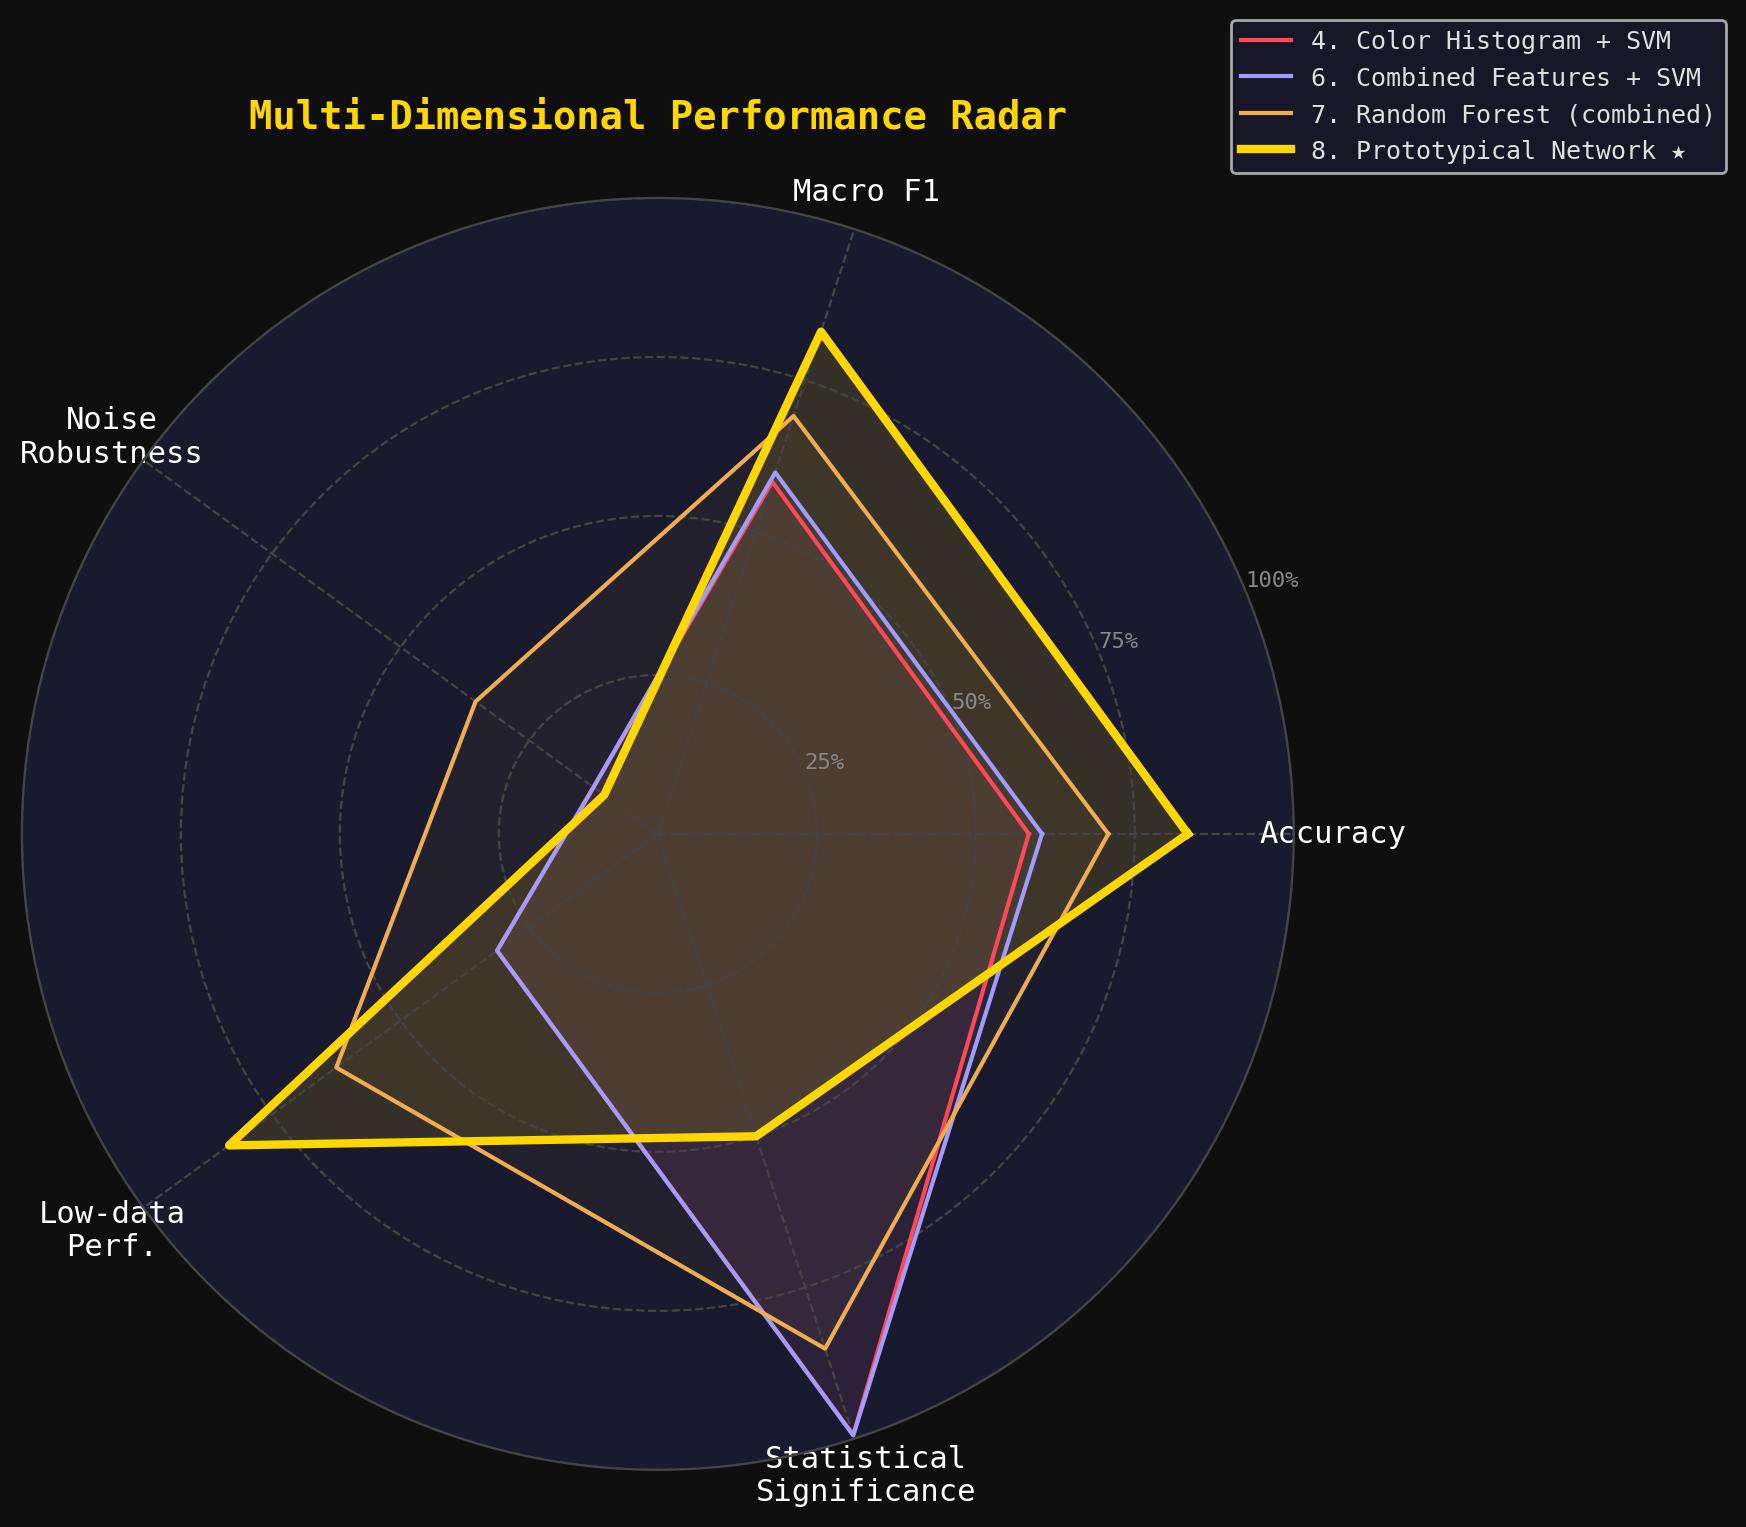

In [14]:
from IPython.display import display, Image as IPImage

outputs = [
    ('01_multi_metric_comparison.png',  '📊 Multi-Metric Comparison'),
    ('02_statistical_significance.png', '🔬 Statistical Significance'),
    ('03_per_class_breakdown.png',      '🍛 Per-Class Breakdown'),
    ('04_data_efficiency.png',          '📉 Data Efficiency'),
    ('05_robustness.png',               '🛡️  Noise Robustness'),
    ('06_confusion_matrices.png',       '🔲 Confusion Matrices'),
    ('07_radar_chart.png',              '🕸️  Performance Radar'),
]
for fname, title in outputs:
    fpath = f'{OUT_DIR}/{fname}'
    if os.path.exists(fpath):
        print(f'\n{title}')
        display(IPImage(fpath))


In [16]:
# ── Confirm all baseline output PNGs saved to Drive ─────────────────────────
import os

expected = [
    '01_multi_metric_comparison.png',
    '02_statistical_significance.png',
    '03_per_class_breakdown.png',
    '04_data_efficiency.png',
    '05_robustness.png',
    '06_confusion_matrices.png',
    '07_radar_chart.png',
]

print("=" * 60)
print("📁 BASELINE OUTPUT FILES — SAVED TO GOOGLE DRIVE")
print("=" * 60)
print(f"Location: {OUT_DIR}")
print()
all_ok = True
for fname in expected:
    fpath = os.path.join(OUT_DIR, fname)
    if os.path.exists(fpath):
        size_kb = os.path.getsize(fpath) / 1024
        print(f"  ✅  {fname}  ({size_kb:.1f} KB)")
    else:
        print(f"  ❌  {fname}  — NOT FOUND (rerun the relevant cell)")
        all_ok = False

print()
if all_ok:
    print("🎉 All 7 baseline comparison plots saved to Google Drive!")
else:
    print("⚠️  Some files missing — rerun the cells above then re-run this cell.")


📁 BASELINE OUTPUT FILES — SAVED TO GOOGLE DRIVE
Location: /content/drive/MyDrive/Research-2026/SriLankanFoodRecognition/baseline_outputs

  ✅  01_multi_metric_comparison.png  (117.9 KB)
  ✅  02_statistical_significance.png  (104.3 KB)
  ✅  03_per_class_breakdown.png  (95.8 KB)
  ✅  04_data_efficiency.png  (155.9 KB)
  ✅  05_robustness.png  (128.5 KB)
  ✅  06_confusion_matrices.png  (163.6 KB)
  ✅  07_radar_chart.png  (310.7 KB)

🎉 All 7 baseline comparison plots saved to Google Drive!
